#imports

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import readsav
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import itertools
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [39]:
path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'
data = readsav(path, verbose=False)
tr_struct = data['tr'][0]
tr_dict = {name: tr_struct[name] for name in tr_struct.dtype.names}
tr_df = pd.DataFrame(tr_dict)
tr_df.to_csv('tr_df.csv', index=False)
print(os.getcwd())

data = readsav(path, verbose=False)
mp_struct = data['mp'][0]
mp_dict = {name: mp_struct[name] for name in mp_struct.dtype.names}
mp_df = pd.DataFrame(mp_dict)
mp_df.to_csv('mp_df.csv', index=False)
print(os.getcwd())

/Users/aldensantoso/Documents/plasma_research/ML Project
/Users/aldensantoso/Documents/plasma_research/ML Project


In [40]:


# 1. Define your original CSV filepaths
mp_filepath = r'/Users/aldensantoso/Documents/plasma_research/ML Project/mp_df.csv'
tr_filepath = r'/Users/aldensantoso/Documents/plasma_research/ML Project/tr_df.csv'

# 2. Load the CSV datasets
print("Loading CSV datasets...")
mp_df = pd.read_csv(mp_filepath)
tr_df = pd.read_csv(tr_filepath)

# 3. Identify the shared shot column dynamically
mp_cols = set(mp_df.columns)
tr_cols = set(tr_df.columns)
common_columns = mp_cols.intersection(tr_cols)

shot_key = None
for col in common_columns:
    if 'shot' in col.lower():
        shot_key = col
        break

# 4. Merge the two datasets cleanly
if shot_key:
    combined_df = pd.merge(mp_df, tr_df, on=shot_key, how='inner')
    print(f"Successfully merged using alignment key: '{shot_key}'")
else:
    # Fallback to horizontal concatenation if row sizes align
    combined_df = pd.concat([mp_df, tr_df], axis=1)
    combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
    print("No common shot key found. Concatenated datasets side-by-side.")

# 5. Export to the destination project path
destination_path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv'
combined_df.to_csv(destination_path, index=False)
print(f"mp dimensions {mp_df.shape}")
print(f"tr dimensions {tr_df.shape}")
print(f"\n[SUCCESS] New matrix created with dimensions: {combined_df.shape}")
print(f"Saved successfully to your machine at:\n--> {destination_path}")

Loading CSV datasets...
No common shot key found. Concatenated datasets side-by-side.
mp dimensions (1051, 35)
tr dimensions (1051, 24)

[SUCCESS] New matrix created with dimensions: (1051, 47)
Saved successfully to your machine at:
--> /Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv


In [41]:
# in this notebook
combined_df = pd.read_csv('/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv')
raw_df = combined_df.copy()
filepath = raw_df




In [42]:
import os
import numpy as np
import pandas as pd
from scipy import stats


def clean_combined_csv(in_csv=None, out_csv=None):
  if in_csv is None:
    in_csv = (
        "/Users/aldensantoso/Documents/plasma_research/ML"
        " Project/combined_plasma_data_clean.csv"
    )
  if out_csv is None:
    out_csv = in_csv.replace(".csv", "_clean.csv")

  if not os.path.exists(in_csv):
    raise FileNotFoundError(in_csv)

  df = pd.read_csv(in_csv)
  df.columns = df.columns.str.strip().str.replace("\ufeff", "")

  # 1. REMOVE DERIVED FEATURES FROM PIPELINE IMMEDIATELY
  derived_to_remove = ["v_A_proxy", "f_norm", "n_norm", "dB2"]
  df = df.drop(columns=[c for c in derived_to_remove if c in df.columns])

  # ...existing code...
  # exact-header candidates (single-element tuples must include trailing comma)
  etau_keys = ("ETAU",)
  nes_keys = ("NES",)
  avgmodef_keys = ("AVGMODEF",)
  avgmodef2_keys = ("AVGMODEF2",)
  bzxr_keys = ("BZXR",)
  te_keys = ("TE",)
  pvol_keys = ("PVOL",)
  raxis_keys = ("RAXIS",)
  tex_keys = ("TEX",)

  etau_col = next((c for c in etau_keys if c in df.columns), None)
  nes_col = next((c for c in nes_keys if c in df.columns), None)
  avgmodef_col = next((c for c in avgmodef_keys if c in df.columns), None)
  avgmodef2_col = next((c for c in avgmodef2_keys if c in df.columns), None)
  bzxr_col = next((c for c in bzxr_keys if c in df.columns), None)
  te_col = next((c for c in te_keys if c in df.columns), None)
  pvol_col = next((c for c in pvol_keys if c in df.columns), None)
  raxis_col = next((c for c in raxis_keys if c in df.columns), None)
  tex_col = next((c for c in tex_keys if c in df.columns), None)

  # fallback: try case-insensitive alternatives
  if etau_col is None:
    etau_col = next((c for c in df.columns if c.strip().lower() in ("etau", "tau_e", "taue")), None)
  if etau_col is None:
    raise KeyError("ETAU / tau_e column not found in CSV")

  if nes_col is None:
    nes_col = next((c for c in df.columns if c.strip().lower() in ("nes", "ne", "n_e")), None)
  if nes_col is None:
    raise KeyError("Electron density column (NES / NE) not found in CSV")
# ...existing code...

  # Coerce numeric where possible
  for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

  # Replace infinities
  df = df.replace([np.inf, -np.inf], np.nan)

  # Enforce physics filters
  df = df[df[etau_col] > 0].copy()  # ETAU > 0
  df = df[df[nes_col] > 0].copy()  # NES / n_e > 0
  df = df[df[avgmodef_col] > 0].copy()  
  df = df[df[avgmodef2_col] > 0].copy()
  df = df[df[bzxr_col] > 0].copy()  
  df = df[df[te_col] > 0].copy()
  df = df[df[pvol_col] > 0].copy() 
  df = df[df[raxis_col] > 0].copy()
  df = df[df[tex_col] > 0].copy() 

  # Drop NaNs
  df = df.dropna(axis=0, how="any").reset_index(drop=True)


  df.to_csv(out_csv, index=False)
  print(f"Saved cleaned CSV: {out_csv}  (rows remaining: {len(df)})")
  return df


# Example usage:
cleaned_df = clean_combined_csv()

Saved cleaned CSV: /Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv  (rows remaining: 1021)


In [43]:
etau_keys = ("ETAU")
nes_keys = ("NES")
avgmodef_keys = ("AVGMODEF")
avgmodef2_keys = ("AVGMODEF2")
bzxr_keys = ("BZXR")
te_keys = ("TE")
pvol_keys = ("PVOL")
raxis_keys = ("RAXIS")
tex_keys = ("TEX")

etau_col = next((c for c in etau_keys if c in df.columns), None)
nes_col = next((c for c in nes_keys if c in df.columns), None)
avgmodef_col = next((c for c in avgmodef_keys if c in df.columns), None)
avgmodef2_col = next((c for c in avgmodef2_keys if c in df.columns), None)
bzxr_col = next((c for c in bzxr_keys if c in df.columns), None)
te_col = next((c for c in te_keys if c in df.columns), None)
pvol_col = next((c for c in pvol_keys if c in df.columns), None)
raxis_col = next((c for c in raxis_keys if c in df.columns), None)
tex_col = next((c for c in tex_keys if c in df.columns), None)
 

print(pd.read_csv("/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv").columns)
print(pd.read_csv("/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv").columns)

Index(['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN',
       'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI',
       'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES',
       'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C',
       'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF',
       'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'CONDE', 'ETAU', 'NEVOL',
       'PVOL', 'RAXIS', 'TEVOL', 'TEX', 'THTAU', 'TOTAU', 'UE0', 'UEVOL',
       'XCONDE'],
      dtype='str')
Index(['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN',
       'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI',
       'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES',
       'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C',
       'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF',
       'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'CONDE', 'ETAU', 'NEVOL',
 

Original dataset size: 1051 rows
Size after enforcing tau_e > 0: 1033 rows


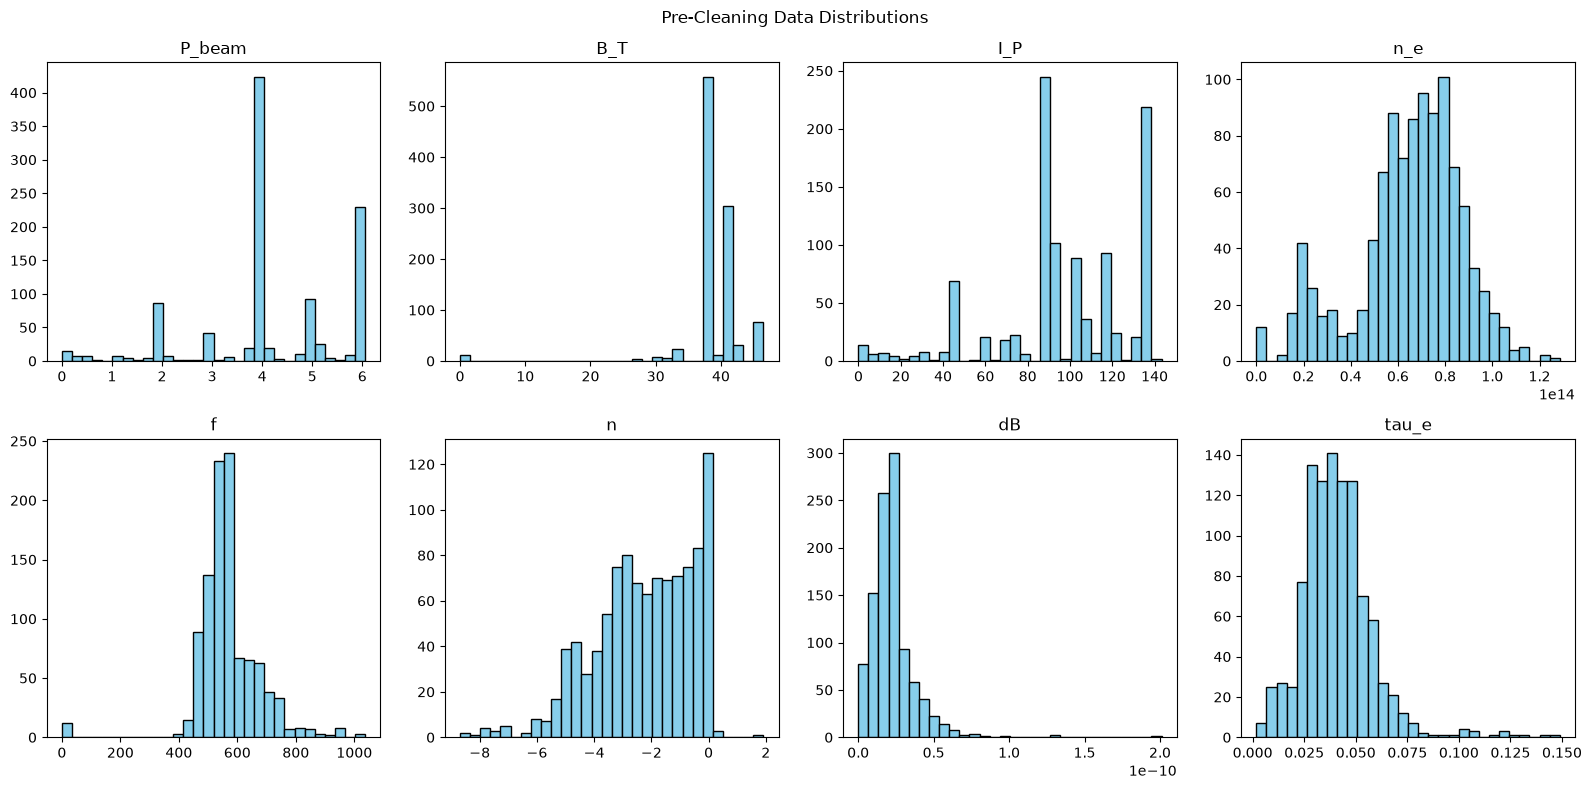

Size after removing extreme outliers (Z > 3): 975 rows

Engineering physics-informed features...
Size after feature engineering and dropna: 975 rows

--- Training Stage 1: The 'Wave Predictor' ---
Wave Predictor R^2 Score: 0.554

--- Training Stage 2: The 'Confinement Predictor' ---
Confinement Predictor R^2 Score: 0.372

Physics Insights (Lasso Coefficients):
  P_beam: -0.00640
  B_T: -0.00173
  I_P: -0.00116
  n_e: 0.00723
  f_norm: 0.00279
  n_norm: 0.00069
  dB2: 0.00300

--- Running Optimization Loop ---

Top 5 Operating Configurations for High Power (P_beam >= 6.0 MW):
 P_beam  B_T  I_P  n_e       f_norm         n_norm          dB2  predicted_tau_e
    6.0  0.3  0.7 5.00 7.120887e+07 -401852.677186 6.275028e-22         0.034939
    6.0  0.3  0.7 4.25 7.120887e+07 -401852.677186 6.275028e-22         0.034939
    6.0  0.3  0.7 3.50 7.120887e+07 -401852.677186 6.275028e-22         0.034939
    6.0  0.3  0.7 2.75 7.120887e+07 -401852.677186 6.275028e-22         0.034939
    6.0  0.3 

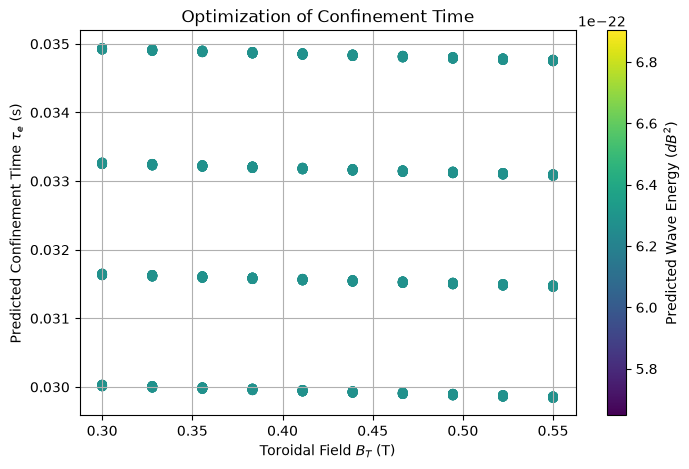

P_beam: -0.006396
B_T: -0.001735
I_P: -0.001159
n_e: 0.007231


In [44]:


# =====================================================================
# STEP 0: DATA EXTRACTION, VISUALIZATION, AND CLEANING
# =====================================================================
def load_and_clean_data(filepath=None):
    """Loads plasma parameters from either a .csv file or an IDL .sav file.

    Plots distributions, removes negative confinement times, and drops
    outliers safely.
    """
    df = None

    if filepath and os.path.exists(filepath):
        if filepath.endswith(".csv"):
            df = pd.read_csv(filepath)

            # 1. Clean whitespace FIRST before mapping
            df.columns = df.columns.str.strip().str.replace("\ufeff", "")
            # Sum individual beam currents into a total
            if {"IBEAM_A", "IBEAM_B", "IBEAM_C"}.issubset(df.columns):
                df["I_BEAM"] = df["IBEAM_A"] + df["IBEAM_B"] + df["IBEAM_C"]

            # 2. Map exact CSV headers
            rename_dict = {
                "PBEAM_TOT": "P_beam",
                "BZXR": "B_T",
                "I_BEAM": "I_P",
                "NES": "n_e",
                "AVGMODEF": "f",
                "AVGMODEN": "n",
                "TOTPWR": "dB",
                "ETAU": "tau_e",
            }
            df = df.rename(columns=rename_dict)

        elif filepath.endswith(".sav"):
            data = readsav(filepath)
            df_mp = data.get("df_mp", data)
            try:
                df = pd.DataFrame({
                    "P_beam": (
                        df_mp["p_beam"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["p_beam"]
                    ),
                    "B_T": (
                        df_mp["b_t"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["b_t"]
                    ),
                    "I_P": (
                        df_mp["i_p"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["i_p"]
                    ),
                    "n_e": (
                        df_mp["n_e"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["n_e"]
                    ),
                    "f": (
                        df_mp["freq"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["freq"]
                    ),
                    "n": (
                        df_mp["mode_num"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["mode_num"]
                    ),
                    "dB": (
                        df_mp["db_amp"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["db_amp"]
                    ),
                    "tau_e": (
                        df_mp["tau_e"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["tau_e"]
                    ),
                })
            except Exception:
                df = pd.DataFrame({
                    "P_beam": data["p_beam"],
                    "B_T": data["b_t"],
                    "I_P": data["i_p"],
                    "n_e": data["n_e"],
                    "f": data["freq"],
                    "n": data["mode_num"],
                    "dB": data["db_amp"],
                    "tau_e": data["tau_e"],
                })

    if df is None or df.empty:
        raise ValueError(
            f"Failed to load data from path: {filepath}. Check if the file"
            " exists and is not empty."
        )

    print(f"Original dataset size: {len(df)} rows")

    # Ensure required columns are present
    required_cols = ["P_beam", "B_T", "I_P", "n_e", "f", "n", "dB", "tau_e"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns after mapping: {missing}. Found columns:"
            f" {list(df.columns)}"
        )

    # 1. Enforce Confinement Time Physics (tau_e > 0)
    df = df[df["tau_e"] > 0].copy()
    print(f"Size after enforcing tau_e > 0: {len(df)} rows")

    # 2. Visualize Data
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Pre-Cleaning Data Distributions")
    for ax, col in zip(axes.flatten(), required_cols):
        ax.hist(df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

    # 3. Robust Outlier Removal (only compute Z-score on columns with variance)
    numeric_df = df[required_cols].copy()
    varying_cols = [col for col in required_cols if numeric_df[col].nunique() > 1]

    if varying_cols:
        z_scores = np.abs(stats.zscore(numeric_df[varying_cols]))
        valid_rows = (z_scores < 3).all(axis=1)
        df_clean = df[valid_rows].copy()
    else:
        df_clean = df.copy()

    print(f"Size after removing extreme outliers (Z > 3): {len(df_clean)} rows")

    if len(df_clean) == 0:
        raise ValueError(
            "Outlier removal resulted in 0 rows. Check dataset for invalid"
            " values."
        )

    return df_clean


# =====================================================================
# STEP 1 & 2: CAUSAL HIERARCHY & PHYSICS-INFORMED FEATURE ENGINEERING
# =====================================================================
def engineer_features(df):
    """Implements Alfvén velocity normalization."""
    print("\nEngineering physics-informed features...")

    # Guard against n_e <= 0 to avoid NaNs/Infs
    df = df[df["n_e"] > 0].copy()

    df["v_A_proxy"] = df["B_T"] / np.sqrt(df["n_e"])
    df["f_norm"] = df["f"] / df["v_A_proxy"]
    df["n_norm"] = df["n"] / df["v_A_proxy"]
    df["dB2"] = df["dB"] ** 2

    X_control_cols = ["P_beam", "B_T", "I_P", "n_e"]
    Y_wave_cols = ["f_norm", "n_norm", "dB2"]
    Y_target_col = ["tau_e"]

    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    print(f"Size after feature engineering and dropna: {len(df)} rows")

    return df, X_control_cols, Y_wave_cols, Y_target_col


# =====================================================================
# STEP 3: THE TWO-STAGE SCIKIT-LEARN PIPELINE
# =====================================================================
def train_pipeline(df, X_control_cols, Y_wave_cols, Y_target_col):
    """Trains stage 1 and stage 2 surrogate models."""
    print("\n--- Training Stage 1: The 'Wave Predictor' ---")
    X1 = df[X_control_cols]
    Y1 = df[Y_wave_cols]

    X1_train, X1_test, Y1_train, Y1_test = train_test_split(
        X1, Y1, test_size=0.2, random_state=42
    )

    scaler_X1 = StandardScaler()
    X1_train_scaled = scaler_X1.fit_transform(X1_train)
    X1_test_scaled = scaler_X1.transform(X1_test)

    wave_model = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42)
    )
    wave_model.fit(X1_train_scaled, Y1_train)

    Y1_pred = wave_model.predict(X1_test_scaled)
    print(f"Wave Predictor R^2 Score: {r2_score(Y1_test, Y1_pred):.3f}")

    print("\n--- Training Stage 2: The 'Confinement Predictor' ---")
    X2 = pd.concat([df[X_control_cols], df[Y_wave_cols]], axis=1)
    Y2 = df[Y_target_col].values.ravel()

    X2_train, X2_test, Y2_train, Y2_test = train_test_split(
        X2, Y2, test_size=0.2, random_state=42
    )

    scaler_X2 = StandardScaler()
    X2_train_scaled = scaler_X2.fit_transform(X2_train)
    X2_test_scaled = scaler_X2.transform(X2_test)

    confinement_model = LassoCV(cv=5, random_state=42)
    confinement_model.fit(X2_train_scaled, Y2_train)

    Y2_pred = confinement_model.predict(X2_test_scaled)
    print(f"Confinement Predictor R^2 Score: {r2_score(Y2_test, Y2_pred):.3f}")

    print("\nPhysics Insights (Lasso Coefficients):")
    for feature, coef in zip(X2.columns, confinement_model.coef_):
        if abs(coef) > 1e-5:
            print(f"  {feature}: {coef:.5f}")

    return wave_model, confinement_model, scaler_X1, scaler_X2


# =====================================================================
# STEP 4: THE OPTIMIZATION LOOP
# =====================================================================
def optimize_operating_space(
    wave_model, confinement_model, scaler_X1, scaler_X2, X_control_cols
):
    """Generates operating grid to locate safe zones."""
    print("\n--- Running Optimization Loop ---")

    P_beam_grid = np.linspace(4.0, 7.0, 10)
    B_T_grid = np.linspace(0.3, 0.55, 10)
    I_P_grid = np.linspace(0.7, 1.3, 5)
    n_e_grid = np.linspace(2.0, 5.0, 5)

    grid = list(itertools.product(P_beam_grid, B_T_grid, I_P_grid, n_e_grid))
    df_grid = pd.DataFrame(grid, columns=X_control_cols)

    X1_sim_scaled = scaler_X1.transform(df_grid)
    predicted_waves = wave_model.predict(X1_sim_scaled)
    df_grid["f_norm"] = predicted_waves[:, 0]
    df_grid["n_norm"] = predicted_waves[:, 1]
    df_grid["dB2"] = predicted_waves[:, 2]

    X2_sim = df_grid[X_control_cols + ["f_norm", "n_norm", "dB2"]]
    X2_sim_scaled = scaler_X2.transform(X2_sim)
    df_grid["predicted_tau_e"] = confinement_model.predict(X2_sim_scaled)

    high_power_shots = df_grid[df_grid["P_beam"] >= 6.0]
    optimized_shots = high_power_shots.sort_values(
        by="predicted_tau_e", ascending=False
    )

    print("\nTop 5 Operating Configurations for High Power (P_beam >= 6.0 MW):")
    print(optimized_shots.head(5).to_string(index=False))

    plt.figure(figsize=(8, 5))
    plt.scatter(
        high_power_shots["B_T"],
        high_power_shots["predicted_tau_e"],
        c=high_power_shots["dB2"],
        cmap="viridis",
    )
    plt.colorbar(label="Predicted Wave Energy ($dB^2$)")
    plt.xlabel("Toroidal Field $B_T$ (T)")
    plt.ylabel("Predicted Confinement Time $\\tau_e$ (s)")
    plt.title("Optimization of Confinement Time")
    plt.grid(True)
    plt.show()

    for name, coef in zip(X_cols, confinement_model.coef_):
        print(f"{name}: {coef:.6f}")


# =====================================================================
# MAIN EXECUTION
# =====================================================================
if __name__ == "__main__":
    csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"

    df_raw = load_and_clean_data(filepath=csv_path)
    df_engineered, X_cols, Y_wave_cols, Y_target_col = engineer_features(
        df_raw
    )
    model1, model2, scale1, scale2 = train_pipeline(
        df_engineered, X_cols, Y_wave_cols, Y_target_col
    )
    optimize_operating_space(model1, model2, scale1, scale2, X_cols)

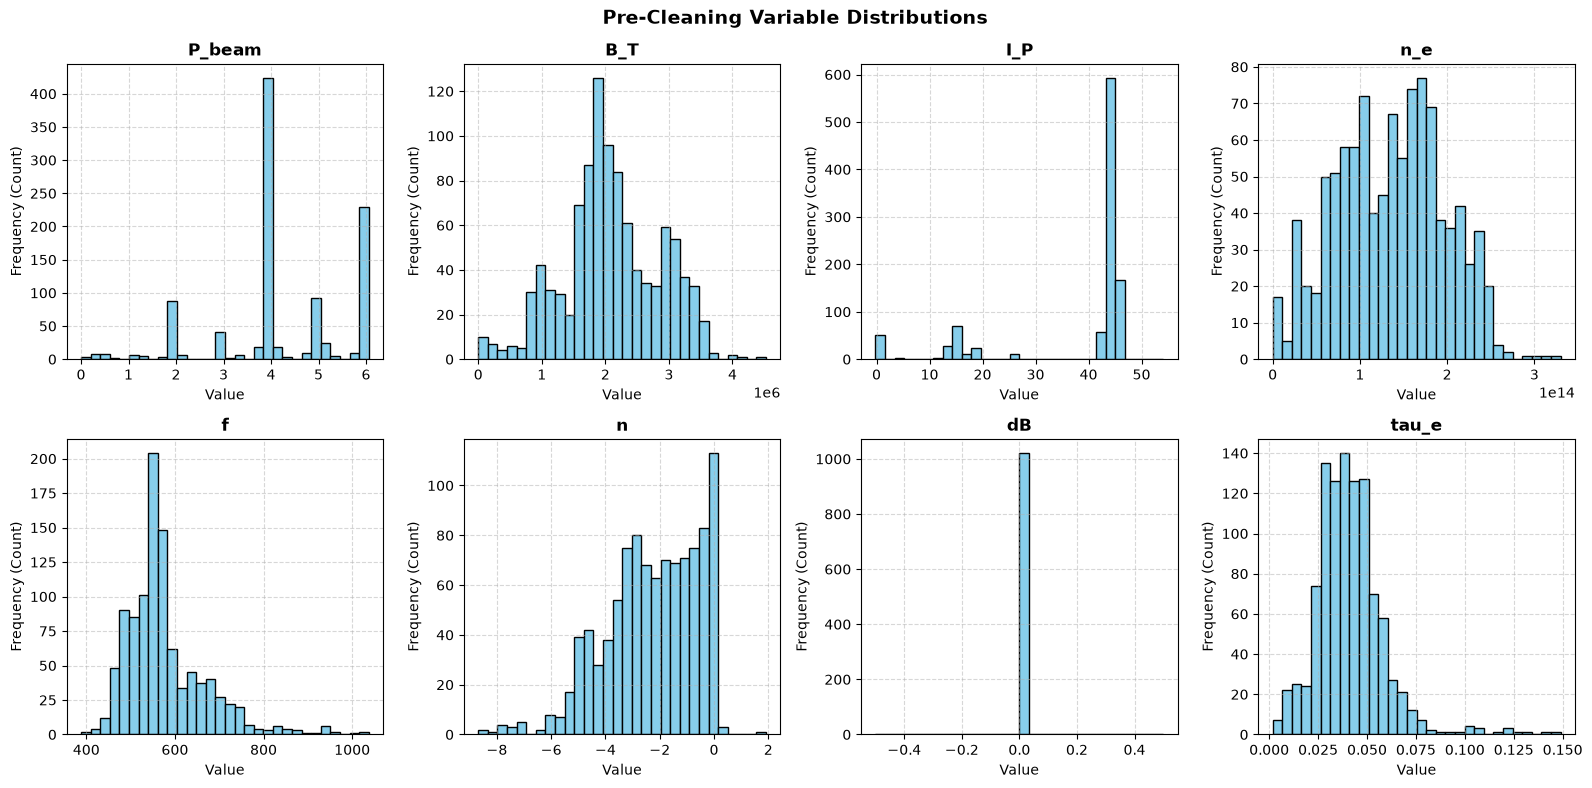

Dataset successfully prepared: 977 clean rows.
Stage 1 (Wave Predictor) R² Score: 0.730
Stage 2 (Confinement Predictor) R² Score: 0.249

Top 5 High-Power Configurations (P_beam >= 6.0 MW):
 P_beam  B_T  I_P  n_e      f_norm    n_norm  dB2  predicted_tau_e
    7.0  0.3  0.7 5.00 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 4.25 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 3.50 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 2.75 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 2.00 4929.741798 -7.993748  0.0         0.059874


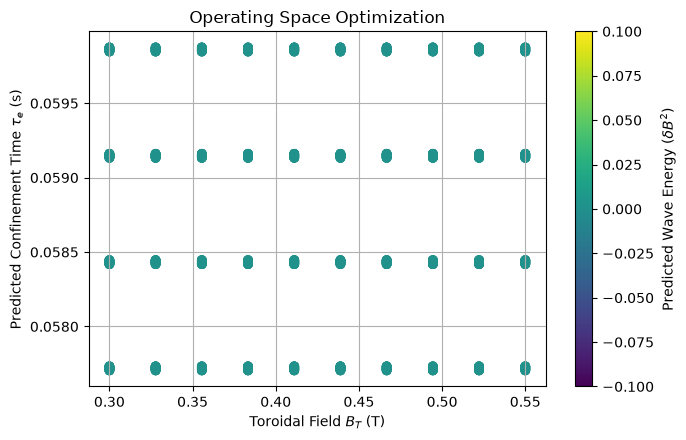

In [45]:

# =====================================================================
# 1. USER CONFIGURATION (MAP YOUR VARIABLES HERE)
# =====================================================================
CSV_PATH = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"

# Map YOUR_CSV_HEADER : PIPELINE_VARIABLE
COLUMN_MAPPING = {
    "PBEAM_TOT": "P_beam",  # Beam Power (MW)
    "BPTE": "B_T",  # Toroidal Field (T)
    "IBEAM_A": "I_P",  # Plasma Current (MA)
    "NEUTT": "n_e",  # Electron Density
    "AVGMODEF": "f",  # Mode Frequency
    "AVGMODEN": "n",  # Mode Number
    "DIFB": "dB",  # Fluctuation Amplitude
    "ETAU": "tau_e",  # Confinement Time (s)
}

# Causal Hierarchy
X_CONTROL_COLS = ["P_beam", "B_T", "I_P", "n_e"]
Y_WAVE_COLS = ["f_norm", "n_norm", "dB2"]
Y_TARGET_COL = "tau_e"


# =====================================================================
# 2. VISUALIZATION & DATA CLEANING
# =====================================================================
def plot_distributions(df, columns, title="Pre-Cleaning Data Distributions"):
    """Plots frequency (count) over value for each physical variable."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, col in zip(axes.flatten(), columns):
        if col in df.columns:
            ax.hist(df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
            ax.set_title(col, fontsize=12, fontweight="bold")
            ax.set_xlabel("Value")
            ax.set_ylabel("Frequency (Count)")
            ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


def load_and_prep_data(filepath, col_map):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found at: {filepath}")

    # Load and clean header strings
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "")
    df = df.rename(columns=col_map)

    # Validate mapped columns
    required = list(col_map.values())
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing mapped columns: {missing}. Available headers in CSV:"
            f" {list(df.columns)}"
        )

    # Filter physical sanity bounds (tau_e > 0 and n_e > 0)
    df = df[(df["tau_e"] > 0) & (df["n_e"] > 0)].copy()

    # --- Plot raw variable distributions before outlier filtering ---
    plot_distributions(df, required, title="Pre-Cleaning Variable Distributions")

    # Outlier removal via Z-score
    var_cols = [c for c in required if df[c].nunique() > 1]
    if var_cols:
        z_scores = np.abs(stats.zscore(df[var_cols]))
        df = df[(z_scores < 3).all(axis=1)].copy()

    print(f"Dataset successfully prepared: {len(df)} clean rows.")
    return df


# =====================================================================
# 3. FEATURE ENGINEERING
# =====================================================================
def engineer_features(df):
    # Alfvén Proxy Normalization: v_A ~ B_T / sqrt(n_e)
    df["v_A_proxy"] = df["B_T"] / np.sqrt(df["n_e"])
    df["f_norm"] = df["f"] / df["v_A_proxy"]
    df["n_norm"] = df["n"] / df["v_A_proxy"]
    df["dB2"] = df["dB"] ** 2

    return df.replace([np.inf, -np.inf], np.nan).dropna()


# =====================================================================
# 4. TWO-STAGE MODEL PIPELINE
# =====================================================================
def train_pipeline(df):
    # --- Stage 1: Control Knobs -> Wave Dynamics ---
    X1 = df[X_CONTROL_COLS]
    Y1 = df[Y_WAVE_COLS]
    X1_tr, X1_te, Y1_tr, Y1_te = train_test_split(
        X1, Y1, test_size=0.2, random_state=42
    )

    scaler_X1 = StandardScaler()
    X1_tr_s = scaler_X1.fit_transform(X1_tr)
    X1_te_s = scaler_X1.transform(X1_te)

    wave_model = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42)
    )
    wave_model.fit(X1_tr_s, Y1_tr)
    print(
        f"Stage 1 (Wave Predictor) R² Score:"
        f" {r2_score(Y1_te, wave_model.predict(X1_te_s)):.3f}"
    )

    # --- Stage 2: Knobs + Wave Dynamics -> Confinement Time ---
    X2 = pd.concat([df[X_CONTROL_COLS], df[Y_WAVE_COLS]], axis=1)
    Y2 = df[Y_TARGET_COL].values.ravel()
    X2_tr, X2_te, Y2_tr, Y2_te = train_test_split(
        X2, Y2, test_size=0.2, random_state=42
    )

    scaler_X2 = StandardScaler()
    X2_tr_s = scaler_X2.fit_transform(X2_tr)
    X2_te_s = scaler_X2.transform(X2_te)

    confinement_model = LassoCV(cv=5, random_state=42)
    confinement_model.fit(X2_tr_s, Y2_tr)
    print(
        f"Stage 2 (Confinement Predictor) R² Score:"
        f" {r2_score(Y2_te, confinement_model.predict(X2_te_s)):.3f}"
    )

    return wave_model, confinement_model, scaler_X1, scaler_X2


# =====================================================================
# 5. OPTIMIZATION GRID SEARCH
# =====================================================================
def optimize_operating_space(
    wave_model, confinement_model, scaler_X1, scaler_X2
):
    grid = list(
        itertools.product(
            np.linspace(4.0, 7.0, 10),  # P_beam range
            np.linspace(0.3, 0.55, 10),  # B_T range
            np.linspace(0.7, 1.3, 5),  # I_P range
            np.linspace(2.0, 5.0, 5),  # n_e range
        )
    )
    df_grid = pd.DataFrame(grid, columns=X_CONTROL_COLS)

    waves_pred = wave_model.predict(scaler_X1.transform(df_grid))
    for i, col in enumerate(Y_WAVE_COLS):
        df_grid[col] = waves_pred[:, i]

    X2_sim = df_grid[X_CONTROL_COLS + Y_WAVE_COLS]
    df_grid["predicted_tau_e"] = confinement_model.predict(
        scaler_X2.transform(X2_sim)
    )

    high_power = df_grid[df_grid["P_beam"] >= 6.0].sort_values(
        by="predicted_tau_e", ascending=False
    )

    print("\nTop 5 High-Power Configurations (P_beam >= 6.0 MW):")
    print(high_power.head(5).to_string(index=False))

    plt.figure(figsize=(7, 4.5))
    plt.scatter(
        high_power["B_T"],
        high_power["predicted_tau_e"],
        c=high_power["dB2"],
        cmap="viridis",
    )
    plt.colorbar(label=r"Predicted Wave Energy ($\delta B^2$)")
    plt.xlabel(r"Toroidal Field $B_T$ (T)")
    plt.ylabel(r"Predicted Confinement Time $\tau_e$ (s)")
    plt.title("Operating Space Optimization")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =====================================================================
# MAIN RUNNER
# =====================================================================
if __name__ == "__main__":
    df_clean = load_and_prep_data(CSV_PATH, COLUMN_MAPPING)
    df_feat = engineer_features(df_clean)
    m1, m2, s1, s2 = train_pipeline(df_feat)
    optimize_operating_space(m1, m2, s1, s2)

In [46]:
print(pd.read_csv("/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv").columns)
print(pd.read_csv("/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv").columns)

Index(['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN',
       'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI',
       'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES',
       'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C',
       'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF',
       'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'CONDE', 'ETAU', 'NEVOL',
       'PVOL', 'RAXIS', 'TEVOL', 'TEX', 'THTAU', 'TOTAU', 'UE0', 'UEVOL',
       'XCONDE'],
      dtype='str')
Index(['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN',
       'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI',
       'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES',
       'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C',
       'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF',
       'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'CONDE', 'ETAU', 'NEVOL',
 

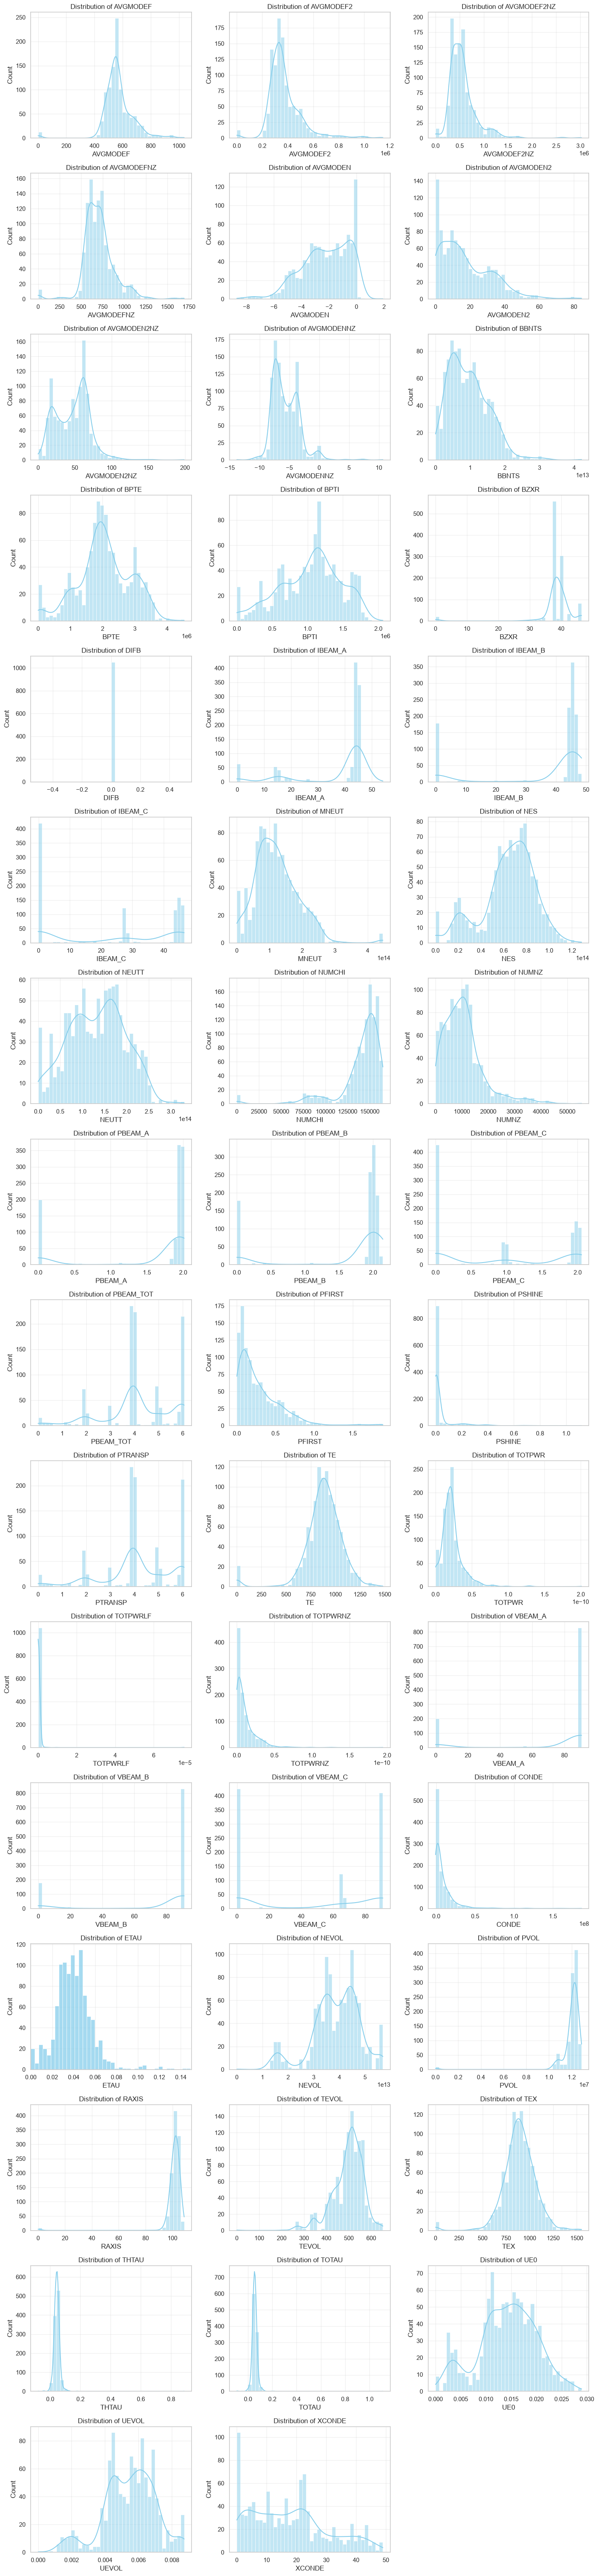

In [47]:
import math
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

csv_path = (
    r"/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"
)
if not os.path.exists(csv_path):
  raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

# Find ETAU (case-insensitive) or tau_e
etau_col = next((c for c in df.columns if c.lower() in ("etau", "tau_e")), None)
if etau_col is None:
  raise KeyError("No ETAU / tau_e column found in CSV")

# --- Grid Configuration ---
n_cols = 3  # Adjust the number of columns in the grid as needed
n_rows = math.ceil(len(df.columns) / n_cols)

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy indexing

# --- Plotting Loop ---
for i, col in enumerate(df.columns):
  ax = axes[i]

  if pd.api.types.is_numeric_dtype(df[col]):
    if col.lower() in ("etau", "tau_e"):
      vals = df[col].dropna().clip(lower=0.0, upper=0.150)
      sns.histplot(vals, bins=40, kde=False, color="skyblue", ax=ax)
      ax.set_title(f"Distribution of {col}")
      ax.set_xlim(0.000, 0.150)
    else:
      sns.histplot(df[col].dropna(), bins=40, kde=True, color="skyblue", ax=ax)
      ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

  else:
    if df[col].nunique() <= 50:
      sns.countplot(
          y=col,
          data=df,
          order=df[col].value_counts().index,
          palette="muted",
          ax=ax,
          hue=col,
          legend=False,
      )
      ax.set_title(f"Value counts for {col}")
    else:
      ax.text(
          0.5,
          0.5,
          f"Non-numeric / >50 unique values ({df[col].nunique()})",
          ha="center",
          va="center",
      )
      ax.set_title(col)
      ax.axis("off")

  ax.grid(alpha=0.3)

# Hide any empty unused subplot slots
for j in range(len(df.columns), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Mapped columns for correlation: {'P_beam': 'PBEAM_TOT', 'f': 'AVGMODEF', 'NES': 'NES', 'BZXR': 'BZXR', 'tau_e': 'ETAU'}


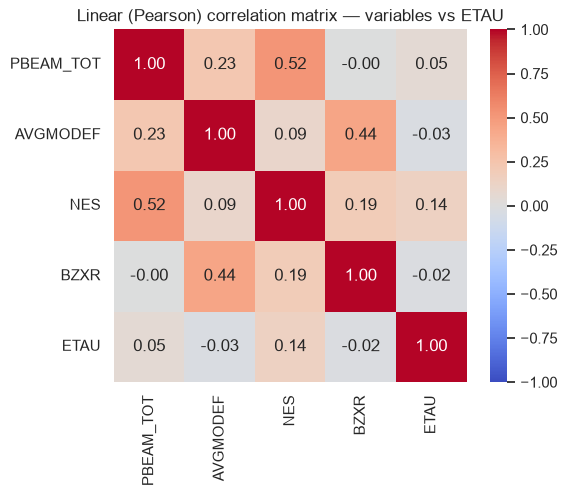


Correlation with ETAU
NES          0.143999
PBEAM_TOT    0.052727
BZXR        -0.023352
AVGMODEF    -0.026541


In [48]:
# ...existing code...
import seaborn as sns, matplotlib.pyplot as plt, numpy as np, pandas as pd, os


csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)
frame = pd.read_csv(csv_path)
frame.columns = frame.columns.str.strip().str.replace("\ufeff", "")

def norm(s): return "".join(ch for ch in str(s).lower() if ch.isalnum())

col_map = {norm(c): c for c in frame.columns}

candidates = {
    "P_beam": ["PBEAM_TOT"],
    "f": ["AVGMODEF"],
    "NES": ["NES"],
    "BZXR": ["BZXR"],
    "tau_e": ["ETAU"]
}



# ...existing code...
found = {}
for key, toks in candidates.items():
    for t in toks:
        t_norm = norm(t)
        matches = [v for k, v in col_map.items() if t_norm in k]
        if matches:
            found[key] = matches[0]
            break

if "tau_e" not in found:
    for alt in ("taue", "etau", "tau_e", "eta_u", "etaU"):
        alt_norm = norm(alt)
        if alt_norm in col_map:
            found["tau_e"] = col_map[alt_norm]
            break
# ...existing code...

print("Mapped columns for correlation:", found)

use_cols = [v for k,v in found.items() if k in ("P_beam","f","NES","BZXR","tau_e")]
df_corr = frame[use_cols].copy().select_dtypes(include=[np.number]).dropna()

if df_corr.empty:
    raise ValueError("No numeric rows after dropna for selected columns.")

corr = df_corr.corr(method="pearson")

# heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Linear (Pearson) correlation matrix — variables vs ETAU")
plt.tight_layout()
plt.show()

# print sorted correlations with tau_e
target_col = found.get("tau_e")
if target_col and target_col in corr.columns:
    corr_with_target = corr[target_col].drop(target_col).sort_values(ascending=False)
    print("\nCorrelation with", target_col)
    print(corr_with_target.to_string())
else:
    print("Target column not found in computed correlation matrix.")
# ...existing code...




Mapped columns for correlation: {'THTAU': 'THTAU', 'TOTAU': 'TOTAU', 'TE': 'BPTE', 'TEX': 'TEX', 'UE0': 'UE0', 'TOTPWR': 'TOTPWR', 'BPTI': 'BPTI', 'PTRANSP': 'PTRANSP', 'AVGMODEN': 'AVGMODEN', 'tau_e': 'ETAU'}


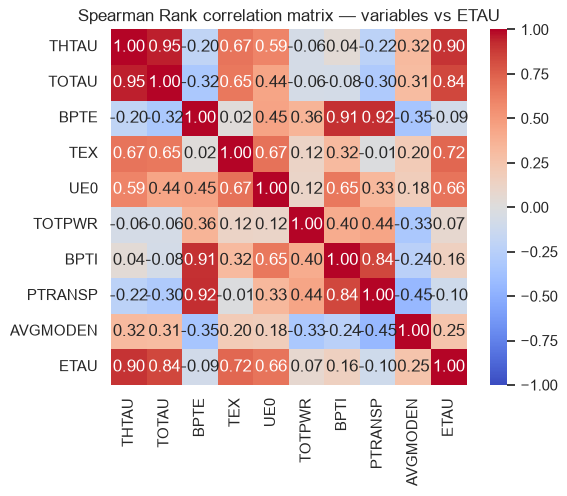


Correlation with ETAU
THTAU       0.903717
TOTAU       0.836585
TEX         0.722865
UE0         0.664727
AVGMODEN    0.251222
BPTI        0.156072
TOTPWR      0.070764
BPTE       -0.086853
PTRANSP    -0.103073


In [49]:
# ...existing code...
import seaborn as sns, matplotlib.pyplot as plt, numpy as np, pandas as pd, os


csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)
frame = pd.read_csv(csv_path)
frame.columns = frame.columns.str.strip().str.replace("\ufeff", "")

def norm(s): return "".join(ch for ch in str(s).lower() if ch.isalnum())

col_map = {norm(c): c for c in frame.columns}

candidates = {
   "THTAU" : ["THTAU"],
   "TOTAU" : ["TOTAU"],
   "TE" : ["TE"],  
   "TEX" : ["TEX"],    
   "UE0" : ["UE0"],
   "TOTPWR" : ["TOTPWR"],
   "BPTI" : ["BPTI"],
   "PTRANSP" : ["PTRANSP"],
   "AVGMODEN" : ["AVGMODEN"]
}



# ...existing code...
found = {}
for key, toks in candidates.items():
    for t in toks:
        t_norm = norm(t)
        matches = [v for k, v in col_map.items() if t_norm in k]
        if matches:
            found[key] = matches[0]
            break

if "tau_e" not in found:
    for alt in ("taue", "etau", "tau_e", "eta_u", "etaU"):
        alt_norm = norm(alt)
        if alt_norm in col_map:
            found["tau_e"] = col_map[alt_norm]
            break
# ...existing code...

print("Mapped columns for correlation:", found)

use_cols = [v for k,v in found.items() if k in ("THTAU","TOTAU","TE","TEX", "UE0", "TOTPWR", "BPTI", "PTRANSP", "AVGMODEN", "tau_e")]
df_corr = frame[use_cols].copy().select_dtypes(include=[np.number]).dropna()

if df_corr.empty:
    raise ValueError("No numeric rows after dropna for selected columns.")

corr = df_corr.corr(method="spearman")

# heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Spearman Rank correlation matrix — variables vs ETAU")
plt.tight_layout()
plt.show()

# print sorted correlations with tau_e
target_col = found.get("tau_e")
if target_col and target_col in corr.columns:
    corr_with_target = corr[target_col].drop(target_col).sort_values(ascending=False)
    print("\nCorrelation with", target_col)
    print(corr_with_target.to_string())
else:
    print("Target column not found in computed correlation matrix.")
# ...existing code...




Computing Spearman matrix for all 47 numeric variables...


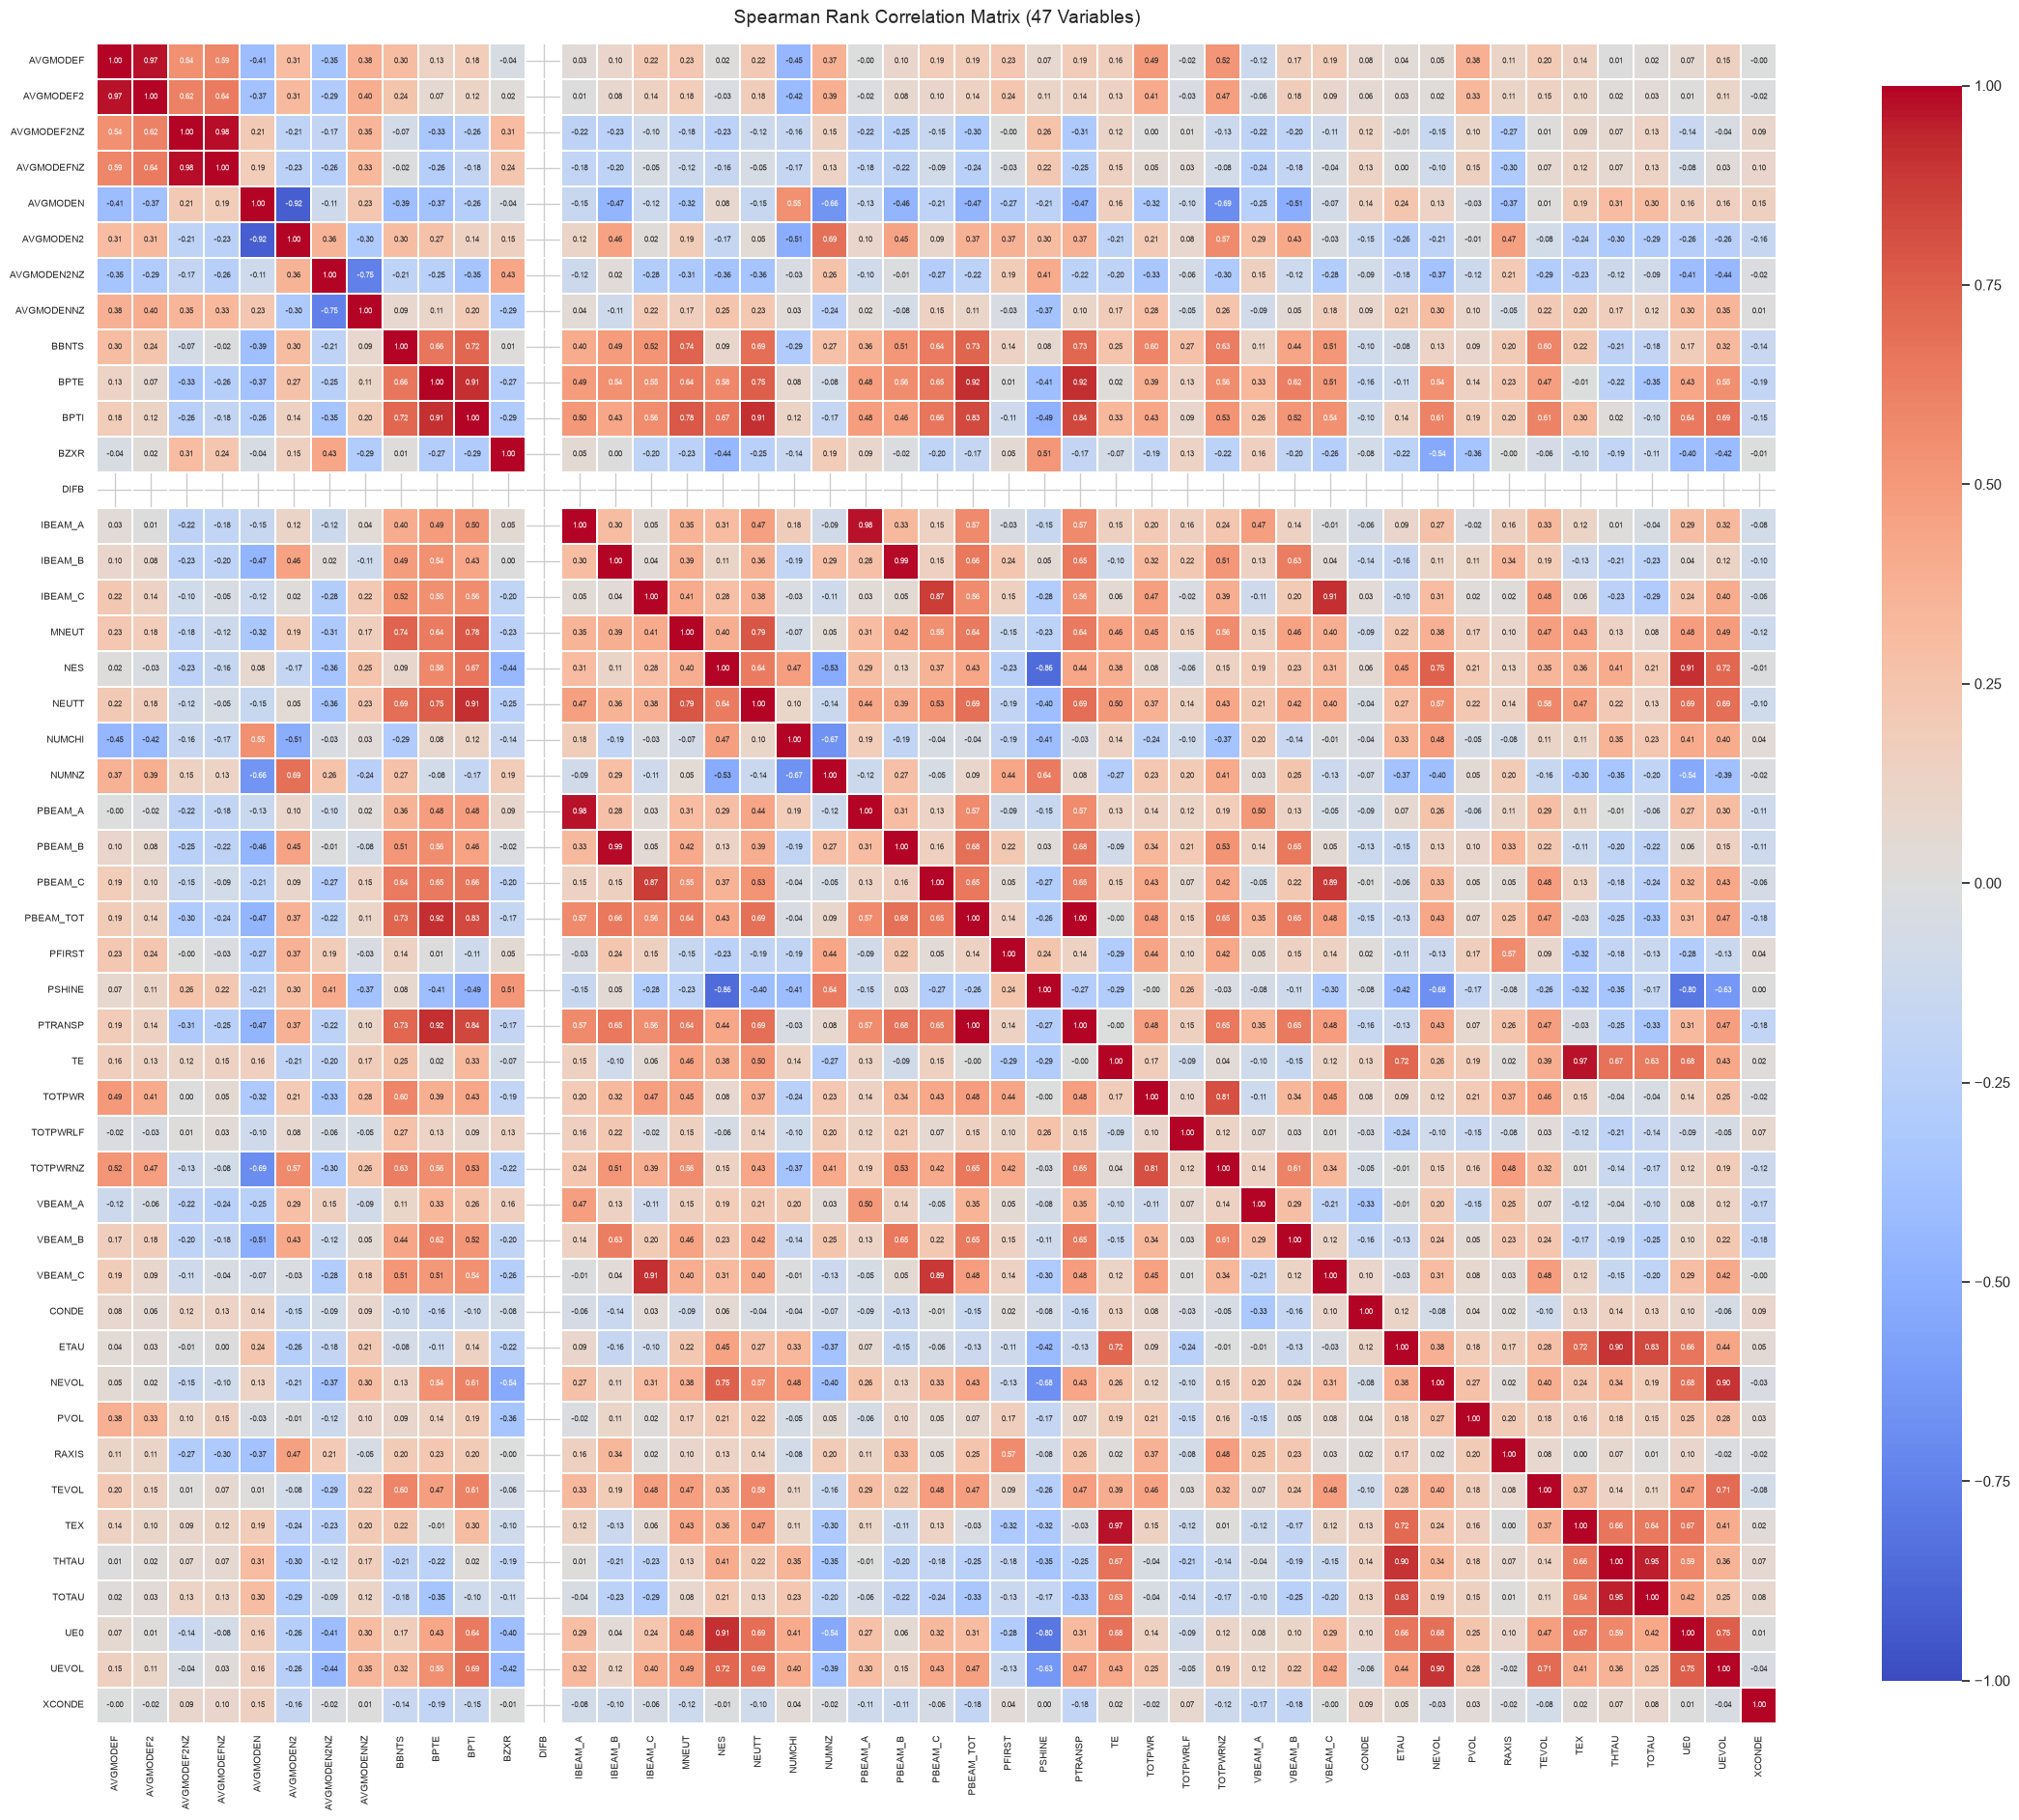


================ Correlation with ETAU ================
THTAU          0.901802
TOTAU          0.833242
TE             0.723733
TEX            0.716720
UE0            0.657090
NES            0.454768
UEVOL          0.440311
NEVOL          0.382198
NUMCHI         0.334063
TEVOL          0.276698
NEUTT          0.274374
AVGMODEN       0.239656
MNEUT          0.220693
AVGMODENNZ     0.212316
PVOL           0.184978
RAXIS          0.166685
BPTI           0.136738
CONDE          0.116232
TOTPWR         0.094398
IBEAM_A        0.094327
PBEAM_A        0.066347
XCONDE         0.050505
AVGMODEF       0.044629
AVGMODEF2      0.033895
AVGMODEFNZ     0.002137
TOTPWRNZ      -0.006519
VBEAM_A       -0.012972
AVGMODEF2NZ   -0.013033
VBEAM_C       -0.034224
PBEAM_C       -0.057091
BBNTS         -0.077923
IBEAM_C       -0.101927
PFIRST        -0.108274
BPTE          -0.111812
PTRANSP       -0.128382
PBEAM_TOT     -0.128942
VBEAM_B       -0.131837
PBEAM_B       -0.148546
IBEAM_B       -0.161464
AVGMODE

In [50]:

# 1. Load Data
csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)

frame = pd.read_csv(csv_path)
frame.columns = frame.columns.str.strip().str.replace("\ufeff", "")


def norm(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())


col_map = {norm(c): c for c in frame.columns}

# 2. Identify target column (tau_e / ETAU) for target-specific correlation output
target_col = None
for alt in ("etau", "taue", "tau_e", "eta_u", "etaU"):
    alt_norm = norm(alt)
    if alt_norm in col_map:
        target_col = col_map[alt_norm]
        break

# 3. Select ALL numerical columns across the entire dataset
df_corr = frame.select_dtypes(include=[np.number]).dropna()

if df_corr.empty:
    raise ValueError("No numeric rows found in the dataframe.")

print(
    f"Computing Spearman matrix for all {df_corr.shape[1]} numeric variables..."
)

# 4. Compute Spearman Correlation Matrix
corr = df_corr.corr(method="spearman")

# 5. Plot Large-Scale Heatmap (Scaled for ~40–50 features)
n_features = corr.shape[1]
fig_dim = max(16, int(n_features * 0.45))  # Dynamically scales figure size

plt.figure(figsize=(fig_dim + 2, fig_dim))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 6},  # Shrinks annotation font size so numbers fit
    cbar_kws={"shrink": 0.8},
)

plt.title(
    f"Spearman Rank Correlation Matrix ({n_features} Variables)",
    fontsize=14,
    pad=15,
)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# 6. Print Target Correlation Ranking
if target_col and target_col in corr.columns:
    corr_with_target = corr[target_col].drop(target_col).sort_values(ascending=False)
    print(
        f"\n================ Correlation with {target_col} ================"
    )
    print(corr_with_target.to_string())
else:
    print(
        "\nTarget column (ETAU/tau_e) was not found in the numeric columns."
    )




================ CLUSTERING SANITY CHECK ================
Silhouette Score: 0.311
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 414 shots (40.9%)
  Cluster 1: 98 shots (9.7%)
  Cluster 2: 327 shots (32.3%)
  Cluster 3: 172 shots (17.0%)

--- Cluster Means ---


,THTAU,TE,UE0,TEX,ETAU
Cluster_Label,,,,,
3,0.061064,1103.166372,0.020149,1103.166372,0.058430
0,0.048457,936.338336,0.016604,936.338336,0.044290
2,0.034243,795.369617,0.011686,809.364015,0.031356
1,0.026131,606.072281,0.004199,670.467981,0.020370


/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_37633/2944164328.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


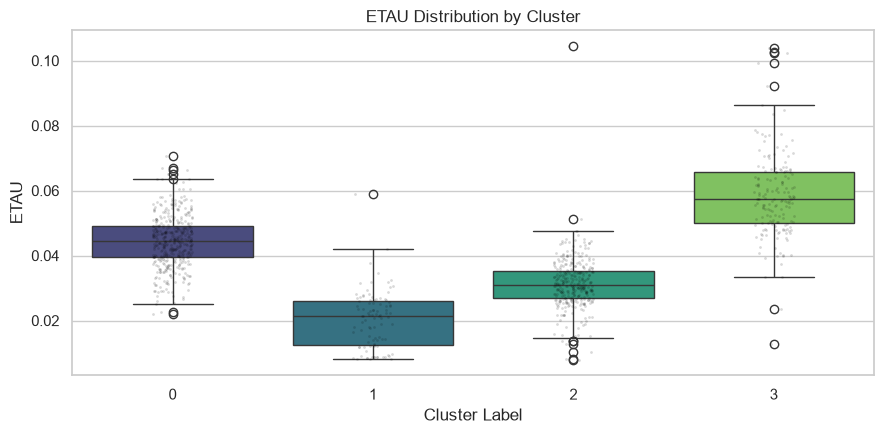

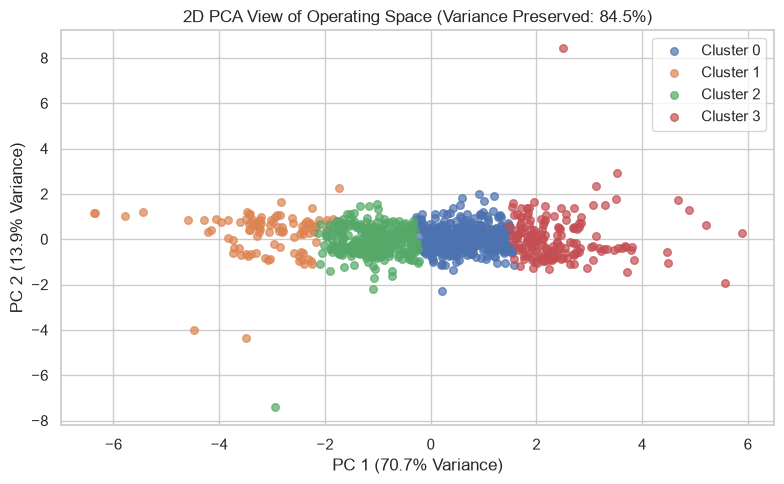

Features used: ['THTAU', 'TE', 'UE0', 'TEX']
Total rows clustered: 1011


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Ensure Cell 14 variables are present
if "frame" not in globals() or "target_col" not in globals():
    raise NameError("Please run Cell 14 first to load `frame` and identify `target_col`.")

# 1. Define Features for Clustering
cluster_vars = [
    "THTAU", "TE", "UE0", "TEX"
]

selected_features = [c for c in cluster_vars if c in frame.columns and pd.api.types.is_numeric_dtype(frame[c])]

# 2. Filter & Clean Working Data
work_cols = selected_features + ([target_col] if target_col in frame.columns else [])
work = frame[work_cols].copy().replace([np.inf, -np.inf], np.nan).dropna()

if target_col in work.columns:
    work = work[work[target_col] > 0]  # Physical constraint
    low, high = work[target_col].quantile(0.01), work[target_col].quantile(0.99)
    work = work[(work[target_col] >= low) & (work[target_col] <= high)].copy()

# 3. Standardize Features & Run K-Means
X = work[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=25)
work["Cluster_Label"] = kmeans.fit_predict(X_scaled)

# --- 4. K-Means & PCA Sanity Checks ---
sil_score = silhouette_score(X_scaled, work["Cluster_Label"])
cluster_counts = work["Cluster_Label"].value_counts().sort_index()

print("================ CLUSTERING SANITY CHECK ================")
print(f"Silhouette Score: {sil_score:.3f}")
if sil_score > 0.5:
    print(" -> Assessment: Strong, well-separated cluster structure.")
elif sil_score > 0.25:
    print(" -> Assessment: Fair structure; expected overlap across continuous plasma regimes.")
else:
    print(" -> Assessment: Low separation; consider adjusting n_clusters or feature selection.")

print("\nCluster Size Balance:")
for label, count in cluster_counts.items():
    pct = (count / len(work)) * 100
    print(f"  Cluster {label}: {count} shots ({pct:.1f}%)")
print("=========================================================")

# 5. Cluster Summary Table
summary_cols = selected_features + ([target_col] if target_col in work.columns else [])
sort_by = target_col if target_col in work.columns else selected_features[0]
cluster_summary = work.groupby("Cluster_Label")[summary_cols].mean().sort_values(by=sort_by, ascending=False)

print("\n--- Cluster Means ---")
display(cluster_summary)

# 6. Plot Target Distribution Across Clusters
if target_col in work.columns:
    plt.figure(figsize=(9, 4.5))
    sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")
    sns.stripplot(data=work, x="Cluster_Label", y=target_col, color="black", alpha=0.15, size=2)
    plt.title(f"{target_col} Distribution by Cluster")
    plt.xlabel("Cluster Label")
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()

# 7. Plot 2D PCA Space with Explained Variance Metrics
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100
total_var = var1 + var2

plt.figure(figsize=(8, 5))
for cl in sorted(work["Cluster_Label"].unique()):
    mask = (work["Cluster_Label"] == cl).values
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1], s=30, alpha=0.7, label=f"Cluster {cl}")

plt.title(f"2D PCA View of Operating Space (Variance Preserved: {total_var:.1f}%)")
plt.xlabel(f"PC 1 ({var1:.1f}% Variance)")
plt.ylabel(f"PC 2 ({var2:.1f}% Variance)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Features used: {selected_features}")
print(f"Total rows clustered: {len(work)}")

In [52]:
pd.DataFrame(pca.components_, columns=selected_features, index=['PC1', 'PC2'])

,THTAU,TE,UE0,TEX
PC1,0.442738,0.525394,0.493501,0.533292
PC2,0.896481,-0.273405,-0.243266,-0.249786


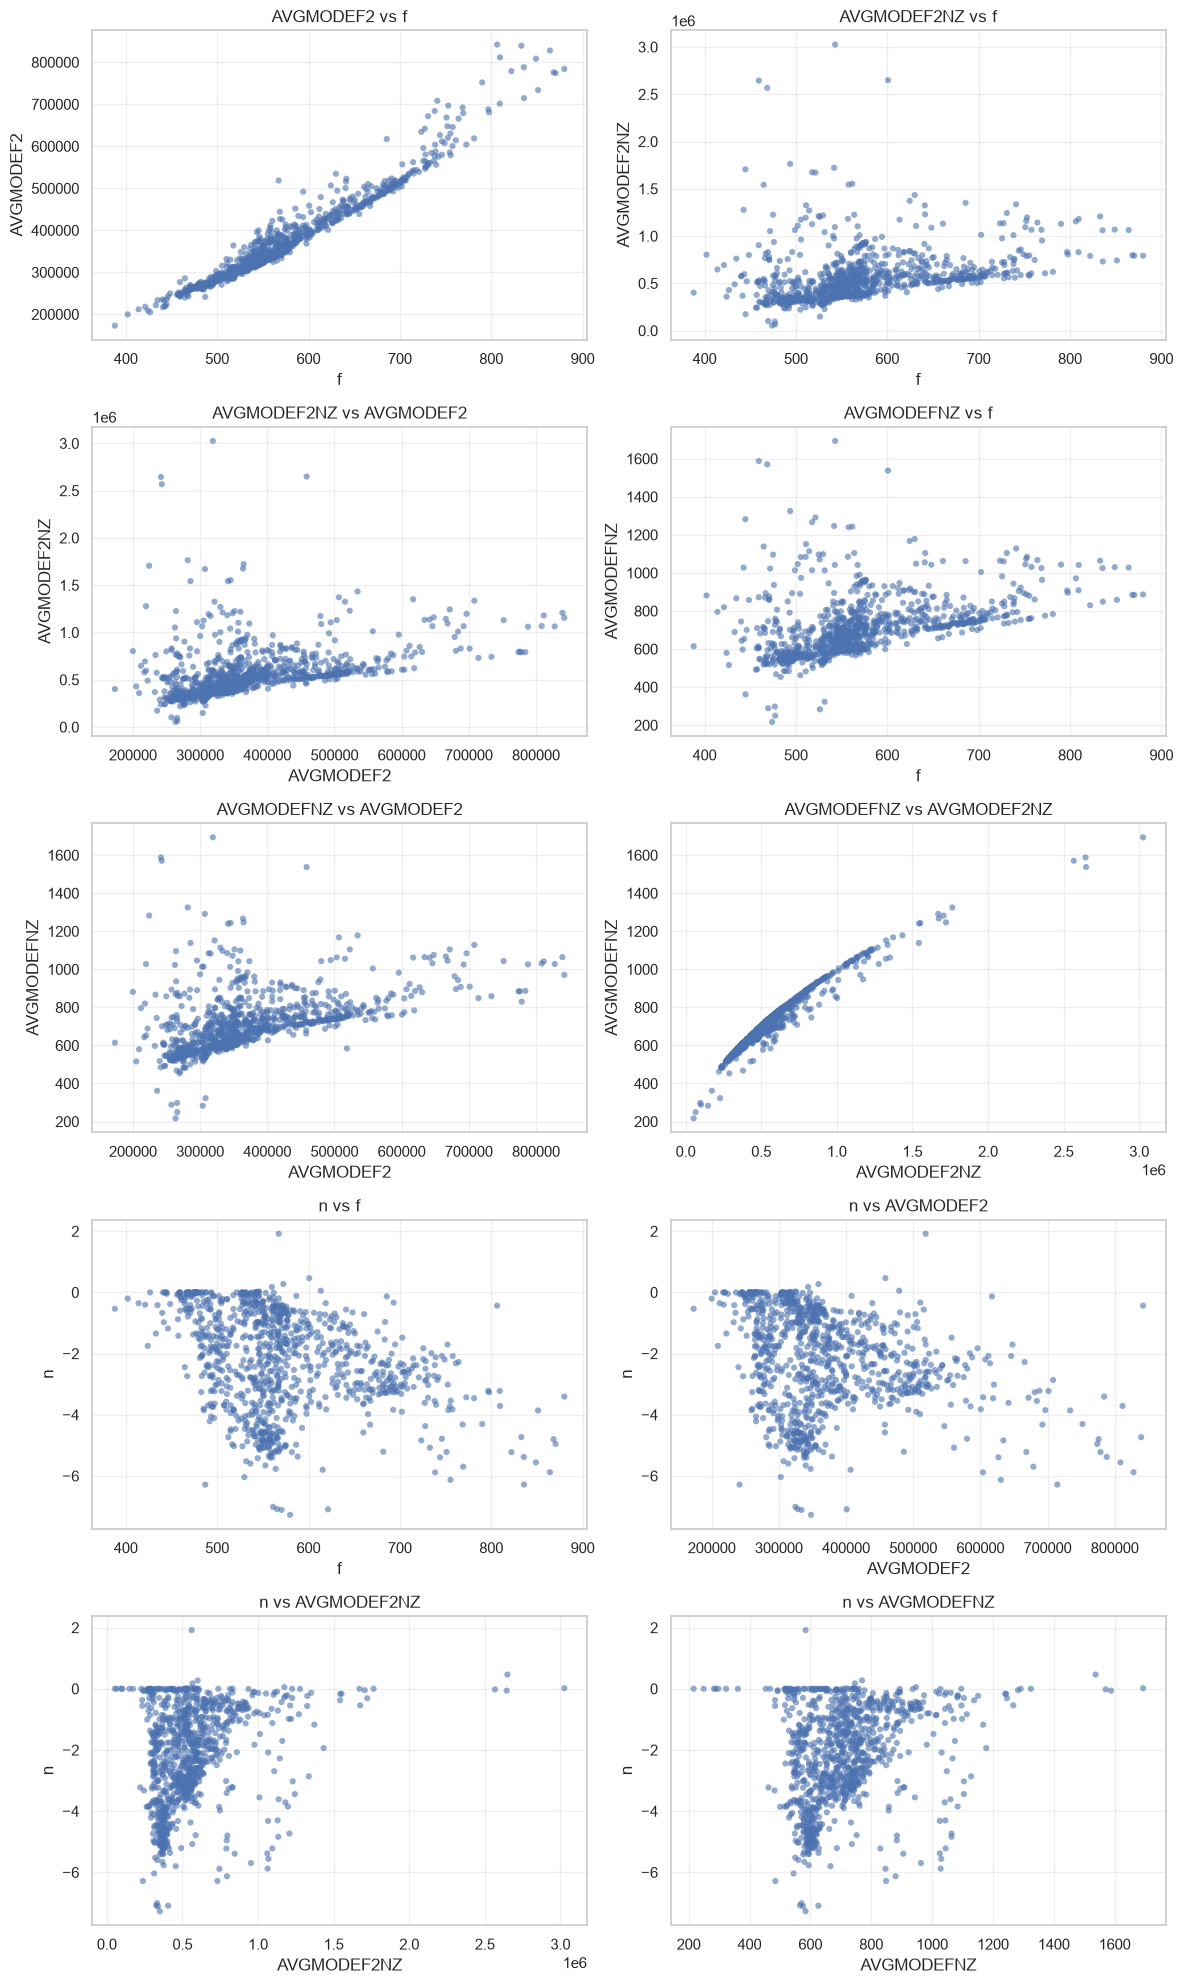

In [53]:
# ...existing code...
import math, seaborn as sns, matplotlib.pyplot as plt, numpy as np, pandas as pd, os

# choose available dataframe
if "df_engineered" in globals():
    df_base = df_engineered.copy()
elif "df_raw" in globals():
    df_base = df_raw.copy()
elif "df" in globals():
    df_base = df.copy()
else:
    csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"
    df_base = pd.read_csv(csv_path)
    df_base.columns = df_base.columns.str.strip().str.replace("\ufeff", "")

# preferred variables (case-insensitive matching)
preferred = ["THTAU", "TE", "UE0", "TEX"]
def norm(s): return "".join(ch for ch in str(s).lower() if ch.isalnum())
colmap = {norm(c): c for c in df_base.columns}
vars_found = [colmap[norm(v)] for v in preferred if norm(v) in colmap]

# fallback to numeric columns if fewer than 5 found
if len(vars_found) < 5:
    vars_found = df_base.select_dtypes(include=[np.number]).columns.tolist()

if len(vars_found) < 2:
    raise ValueError("Not enough numeric columns to plot scatter pairs.")

# build lower-triangle pairs (y vs x) and take first 10
pairs = []
for i in range(len(vars_found)):
    for j in range(i):
        pairs.append((vars_found[i], vars_found[j]))
pairs = pairs[:10]

# plot grid (5x2)
n = len(pairs)
cols = 2
rows = math.ceil(n/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

for ax, (ycol, xcol) in zip(axes, pairs):
    # drop NA for the two columns
    sub = df_base[[xcol, ycol]].dropna()
    ax.scatter(sub[xcol], sub[ycol], s=20, alpha=0.6, edgecolor='none')
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{ycol} vs {xcol}")
    ax.grid(alpha=0.3)

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
# ...existing code...

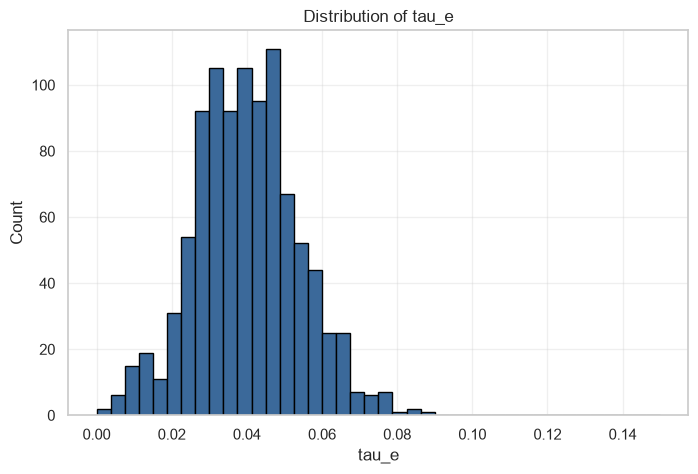

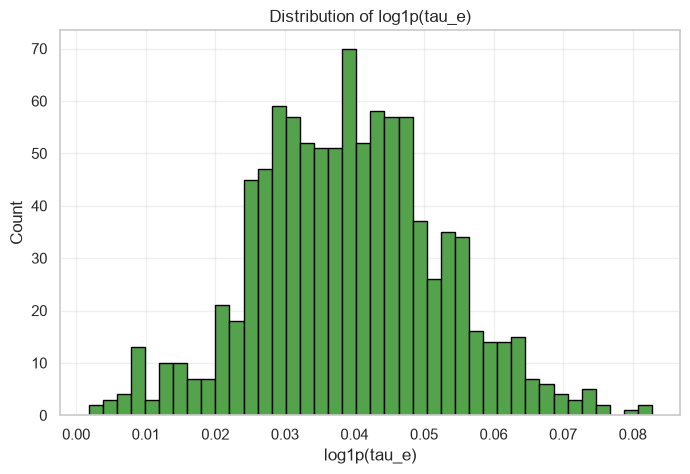

Skewness of tau_e: 0.145
Skewness of log1p(tau_e): 0.102


In [60]:
# Build the dataframe only from notebook-defined objects
if "df_raw" not in globals():
    df_raw = load_and_clean_data(filepath=filepath)

def inspect_local_target(frame):
    target_candidates = ("tau_e", "ETAU", "etau")
    target = next((c for c in target_candidates if c in frame.columns), None)
    if target is None:
        raise ValueError("No valid target column found in the local dataframe.")

    work = frame.select_dtypes(include=[np.number]).copy()
    corr = work.corr(numeric_only=True)

 

    plt.figure(figsize=(8, 5))
    plt.hist(frame[target].dropna(), bins=40, range = (0, 0.15), color="#3B699A", edgecolor="black")
    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()

    log_target = np.log1p(frame[target].clip(lower=0))
    plt.figure(figsize=(8, 5))
    plt.hist(log_target.dropna(), bins=40, color="#54A24B", edgecolor="black")
    plt.title(f"Distribution of log1p({target})")
    plt.xlabel(f"log1p({target})")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Skewness of {target}: {frame[target].skew():.3f}")
    print(f"Skewness of log1p({target}): {log_target.skew():.3f}")

    return target, corr

target_col, corr_matrix = inspect_local_target(df_raw)

In [55]:
# python
import pandas as pd, os
p = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"
df = pd.read_csv(p)
desired = ["P_beam","B_T","I_P","n_e","f","n","dB","tau_e"]
def norm(s): return "".join(ch for ch in str(s).lower() if ch.isalnum())
col_map = {norm(c): c for c in df.columns}
suggest = {}
for d in desired:
    k = norm(d)
    if k in col_map:
        suggest[d] = col_map[k]
    else:
        cand = [c for nk,c in col_map.items() if k in nk or nk in k]
        suggest[d] = cand if cand else None
print("Suggested mapping (desired -> actual):")
for k,v in suggest.items(): print(f"{k} -> {v}")
print("\nActual columns:", list(df.columns))
print("Missing desired keys:", [k for k,v in suggest.items() if v is None])

Suggested mapping (desired -> actual):
P_beam -> ['PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT']
B_T -> None
I_P -> None
n_e -> ['MNEUT', 'NES', 'NEUTT', 'PSHINE', 'NEVOL']
f -> ['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'DIFB', 'PFIRST', 'TOTPWRLF']
n -> ['AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN', 'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'MNEUT', 'NES', 'NEUTT', 'NUMCHI', 'NUMNZ', 'PSHINE', 'PTRANSP', 'TOTPWRNZ', 'CONDE', 'NEVOL', 'XCONDE']
dB -> None
tau_e -> None

Actual columns: ['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN', 'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI', 'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES', 'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF', 'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'CONDE', 'ETAU', 'NEVOL', 'PVOL', 'RAXIS', 'TEVOL', 'TEX', 'THTAU', 'TOTAU', 'UE0', 'UEVOL', 'XCONDE']
Missing desir

In [56]:


# Build the dataframe from notebook-defined objects only
if "df_raw" not in globals():
    df_raw = load_and_clean_data(filepath=None)

if "df_engineered" not in globals():
    df_engineered, X_cols, Y_wave_cols, Y_target_col = engineer_features(df_raw)

# Use the engineered features from this notebook
feature_cols = ['P_beam', 'B_T', 'I_P', 'n_e', 'f_norm', 'n_norm', 'dB2']

X = df_engineered[feature_cols].copy()
y = df_engineered['tau_e'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Target transform for skewed tau_e
y_train_log = np.log1p(y_train)

model = make_pipeline(
    RobustScaler(),
    LassoCV(cv=5, random_state=42)
)

model.fit(X_train, y_train_log)

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"R2: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R2: 0.392
RMSE: 0.010


In [57]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler

def train_pipeline(df, X_control_cols, Y_wave_cols, Y_target_col):
    """
    Trains the 2-stage surrogate model using RobustScaler for the confinement stage.
    """
    print("\n--- Training Stage 1: The 'Wave Predictor' ---")
    X1 = df[X_control_cols]
    Y1 = df[Y_wave_cols]

    X1_train, X1_test, Y1_train, Y1_test = train_test_split(
        X1, Y1, test_size=0.2, random_state=42
    )

    # Wave model: tree-based, scaling is not essential here
    wave_model = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42)
    )
    wave_model.fit(X1_train, Y1_train)

    Y1_pred = wave_model.predict(X1_test)
    print(f"Wave Predictor R^2 Score: {r2_score(Y1_test, Y1_pred):.3f}")

    print("\n--- Training Stage 2: The 'Confinement Predictor' ---")
    X2 = pd.concat([df[X_control_cols], df[Y_wave_cols]], axis=1)
    Y2 = df[Y_target_col].values.ravel()

    X2_train, X2_test, Y2_train, Y2_test = train_test_split(
        X2, Y2, test_size=0.2, random_state=42
    )

    # Use the same scaling strategy as your later model
    confinement_model = make_pipeline(
        RobustScaler(),
        LassoCV(cv=5, random_state=42)
    )

    y_train_log = np.log1p(Y2_train)
    confinement_model.fit(X2_train, y_train_log)

    Y2_pred_log = confinement_model.predict(X2_test)
    Y2_pred = np.expm1(Y2_pred_log)

    print(f"Confinement Predictor R^2 Score: {r2_score(Y2_test, Y2_pred):.3f}")

    return wave_model, confinement_model


def optimize_operating_space(wave_model, confinement_model, X_control_cols):
    print("\n--- Running Optimization Loop ---")

    P_beam_grid = np.linspace(4.0, 7.0, 10)
    B_T_grid = np.linspace(0.3, 0.55, 10)
    I_P_grid = np.linspace(0.7, 1.3, 5)
    n_e_grid = np.linspace(2.0, 5.0, 5)

    grid = list(itertools.product(P_beam_grid, B_T_grid, I_P_grid, n_e_grid))
    df_grid = pd.DataFrame(grid, columns=X_control_cols)

    # Stage 1: predict waves
    predicted_waves = wave_model.predict(df_grid[X_control_cols])
    df_grid['f_norm'] = predicted_waves[:, 0]
    df_grid['n_norm'] = predicted_waves[:, 1]
    df_grid['dB2'] = predicted_waves[:, 2]

    # Stage 2: predict tau_e using the pipeline with RobustScaler inside
    X2_grid = df_grid[X_control_cols + ['f_norm', 'n_norm', 'dB2']]
    df_grid['predicted_tau_e'] = np.expm1(
        confinement_model.predict(X2_grid)
    )

    high_power_shots = df_grid[df_grid['P_beam'] >= 6.0]
    optimized_shots = high_power_shots.sort_values(by='predicted_tau_e', ascending=False)

    print("\nTop 5 Operating Configurations for High Power (P_beam >= 6.0 MW):")
    print(optimized_shots.head(5).to_string(index=False))
    return df_grid

Original dataset size: 1051 rows
Size after enforcing tau_e > 0: 1033 rows


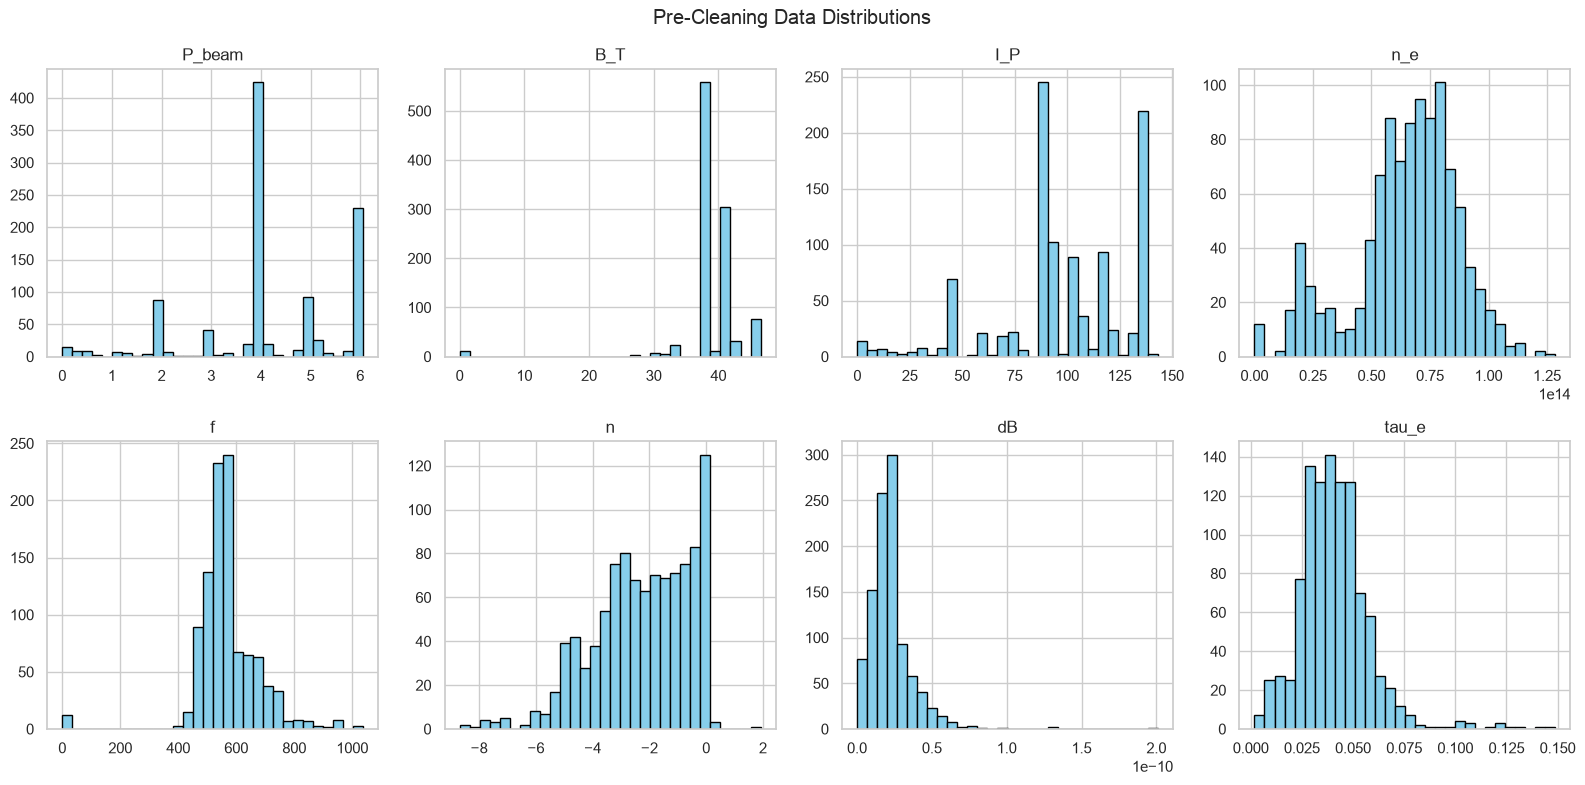

Size after removing extreme outliers (Z > 3): 975 rows


ValueError: too many values to unpack (expected 4)

In [58]:
if __name__ == "__main__":
    p = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv"
    df_raw = load_and_clean_data(p)
    df_engineered, X_cols, Y_wave_cols, Y_target_col = engineer_features(df_raw)

    model1, model2 = train_pipeline(df_engineered, X_cols, Y_wave_cols, Y_target_col)
    optimize_operating_space(model1, model2, X_cols)

Beam Properties


In [ ]:

from sklearn.model_selection import train_test_split, KFold, cross_val_score
# --- HELPER FUNCTION ---
def clean_idl_var(arr):
    """Formats IDL byte-order arrays into standard flat numpy arrays."""
    arr = np.asanyarray(arr)
    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
    return arr.flatten().astype(np.float64)

# --- 1. DATA EXTRACTION & CLEANING ---
# Replace with your actual local path
local_path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'
data = readsav(local_path, python_dict=True)

mp_struct = data['mp'][0]

# Features focusing on beam combinations and global parameters
beam_features = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C']
core_features = ['TOTPWR', 'TE', 'NEUTT', 'AVGMODEN', 'NUMCHI']
target_name = 'ETAU'

data_dict = {}
for name in beam_features + core_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

df = pd.DataFrame(data_dict)

# Filter invalid confinement times and extreme outliers
df_clean = df[df[target_name] > 0].copy()
lower_bound = df_clean[target_name].quantile(0.01)
upper_bound = df_clean[target_name].quantile(0.99)
df_clean = df_clean[(df_clean[target_name] >= lower_bound) & (df_clean[target_name] <= upper_bound)]

# --- 2. UNSUPERVISED CLUSTERING (Beam Regimes) ---
# We isolate the injected power of the 3 beams to find injection regimes
X_beams = df_clean[['PBEAM_A', 'PBEAM_B', 'PBEAM_C']]

# Scale before clustering so large power numbers don't warp the distance metrics
scaler_cluster = StandardScaler()
X_beams_scaled = scaler_cluster.fit_transform(X_beams)

# Find 4 distinct beam combinations (you can tune n_clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Beam_Regime'] = kmeans.fit_predict(X_beams_scaled)

# --- 3. SUPERVISED LEARNING (Random Forest) ---
# We predict log10(ETAU) to linearize the power-law physics
y = np.log10(df_clean['ETAU']).values

# Include the cluster labels as a categorical feature
features_for_model = beam_features + core_features + ['Beam_Regime']
X = df_clean[features_for_model].values

# Scale the final feature matrix
scaler_rf = StandardScaler()
X_scaled = scaler_rf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# --- 4. EVALUATION ---
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest R^2 Score (Log10 ETAU): {r2:.4f}")

# Cross-validation for robust scoring
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=kf, scoring='r2')
print(f"5-Fold CV R^2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Random Forest R^2 Score (Log10 ETAU): 0.7243
5-Fold CV R^2: 0.7218 (+/- 0.0379)



--- Physics Profiles of Beam Clusters ---


,PBEAM_A,PBEAM_B,PBEAM_C,TOTPWR,ETAU
Beam_Regime,,,,,
0,1.959372,2.006826,1.960906,3.233517e-11,0.034456
1,1.949516,1.994900,0.291557,1.860025e-11,0.041782
2,1.506521,0.040817,0.729796,1.077573e-11,0.039499
3,-0.000368,1.961538,1.497812,3.083968e-11,0.045673


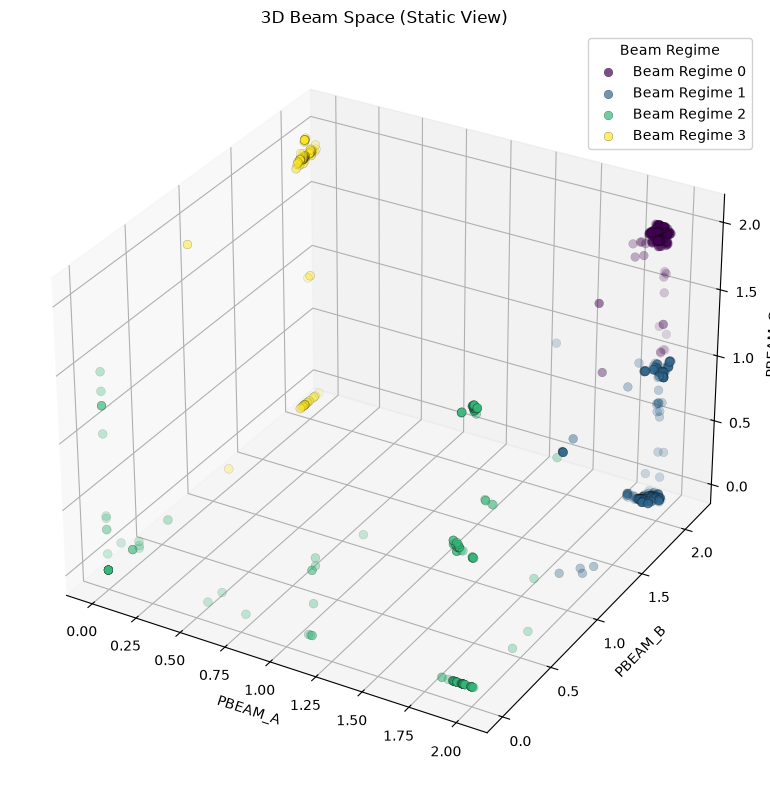

In [ ]:
# ...existing code...
# Group by the new clusters and see the average power distribution
cluster_profiles = df_clean.groupby('Beam_Regime')[['PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'TOTPWR', 'ETAU']].mean()
print("\n--- Physics Profiles of Beam Clusters ---")
display(cluster_profiles)

# Visualize the 3D Beam Space (static, non-interactive)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

regimes = sorted(df_clean['Beam_Regime'].unique())
cmap = plt.cm.viridis

for i, regime in enumerate(regimes):
    subset = df_clean[df_clean['Beam_Regime'] == regime]
    color = cmap(i / (len(regimes) - 1 if len(regimes) > 1 else 1))
    ax.scatter(
        subset['PBEAM_A'],
        subset['PBEAM_B'],
        subset['PBEAM_C'],
        color=color,
        s=40,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.2,
        label=f'Beam Regime {regime}'
    )

ax.set_xlabel('PBEAM_A')
ax.set_ylabel('PBEAM_B')
ax.set_zlabel('PBEAM_C')
ax.set_title('3D Beam Space (Static View)')

ax.legend(title='Beam Regime', loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


--- ETAU summary by Beam Regime ---


,Beam_Regime,n,mean_eta,median_eta,std_eta,q25_eta,q75_eta
0,0,250,0.034456,0.033290,0.009531,0.027282,0.041637
1,1,419,0.041782,0.040832,0.011555,0.033238,0.048464
2,2,179,0.039499,0.039040,0.020435,0.023269,0.054753
3,3,163,0.045673,0.047344,0.016875,0.033258,0.055955


/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_37633/4177646330.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis")


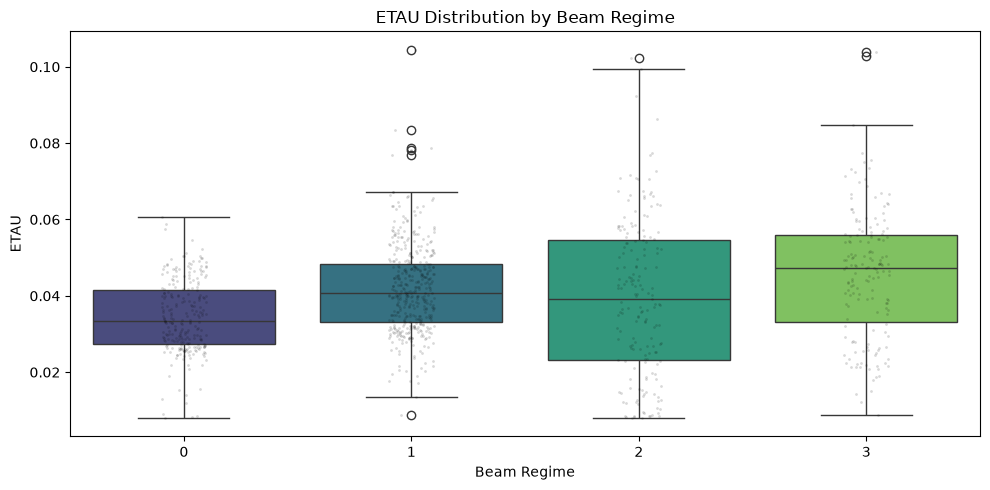

/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_37633/4177646330.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x="Beam_Regime", y="mean_eta", palette="viridis")


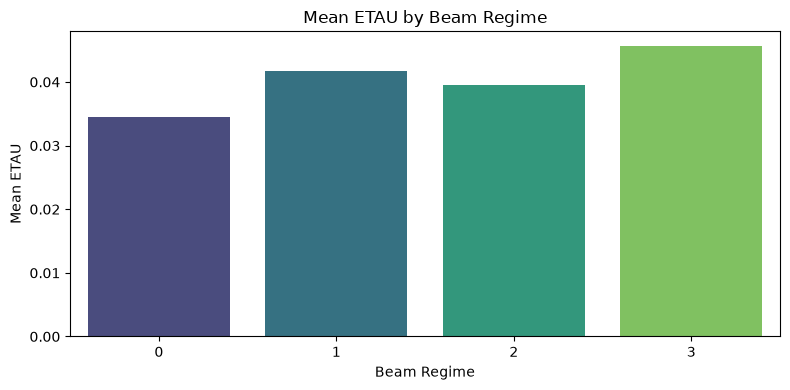

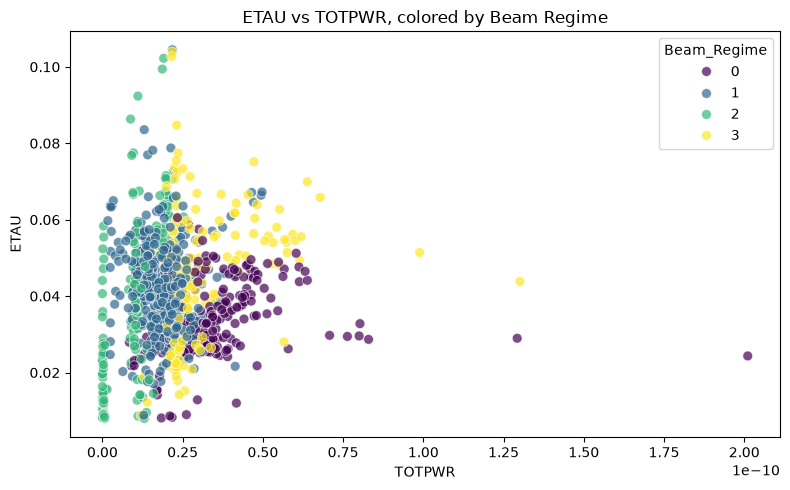

In [ ]:
# Cluster summary with ETAU effect
cluster_summary = (
    df_clean.groupby("Beam_Regime")
    .agg(
        n=("ETAU", "size"),
        mean_eta=("ETAU", "mean"),
        median_eta=("ETAU", "median"),
        std_eta=("ETAU", "std"),
        q25_eta=("ETAU", lambda s: s.quantile(0.25)),
        q75_eta=("ETAU", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)

print("\n--- ETAU summary by Beam Regime ---")
display(cluster_summary)

# 1) Boxplot: ETAU distribution by regime
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis")
sns.stripplot(data=df_clean, x="Beam_Regime", y="ETAU", color="black", alpha=0.15, size=2)
plt.title("ETAU Distribution by Beam Regime")
plt.xlabel("Beam Regime")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

# 2) Bar plot: mean ETAU by regime
plt.figure(figsize=(8, 4))
sns.barplot(data=cluster_summary, x="Beam_Regime", y="mean_eta", palette="viridis")
plt.title("Mean ETAU by Beam Regime")
plt.xlabel("Beam Regime")
plt.ylabel("Mean ETAU")
plt.tight_layout()
plt.show()

# 3) Scatter: show how ETAU changes with total power and regime
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="TOTPWR",
    y="ETAU",
    hue="Beam_Regime",
    palette="viridis",
    s=50,
    alpha=0.7
)
plt.title("ETAU vs TOTPWR, colored by Beam Regime")
plt.xlabel("TOTPWR")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_37633/187327427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis", inner="box")


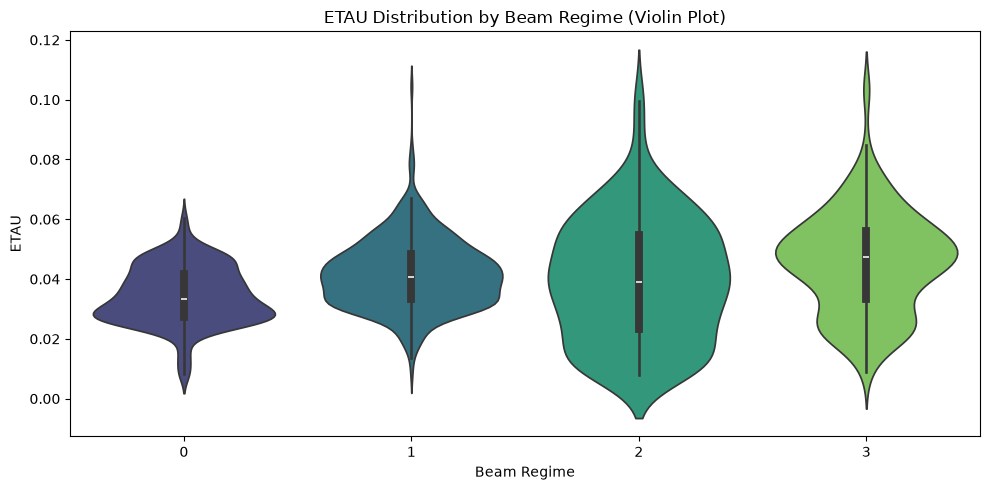

In [ ]:
# 4) Violin plot: ETAU distribution by regime
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis", inner="box")
plt.title("ETAU Distribution by Beam Regime (Violin Plot)")
plt.xlabel("Beam Regime")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

ETAU R^2: 0.744
ETAU RMSE: 0.007

--- Beam Regime Profiles ---


,PBEAM_A,PBEAM_B,PBEAM_C,TOTPWR,ETAU
Beam_Regime,,,,,
0,1.960898,2.018359,1.744396,3.110876e-11,0.034104
1,1.943355,1.449509,0.432699,1.758936e-11,0.043994
2,-0.000357,1.907873,1.457691,3.023973e-11,0.045113
3,1.161068,0.839172,0.139874,3.338866e-12,0.032435


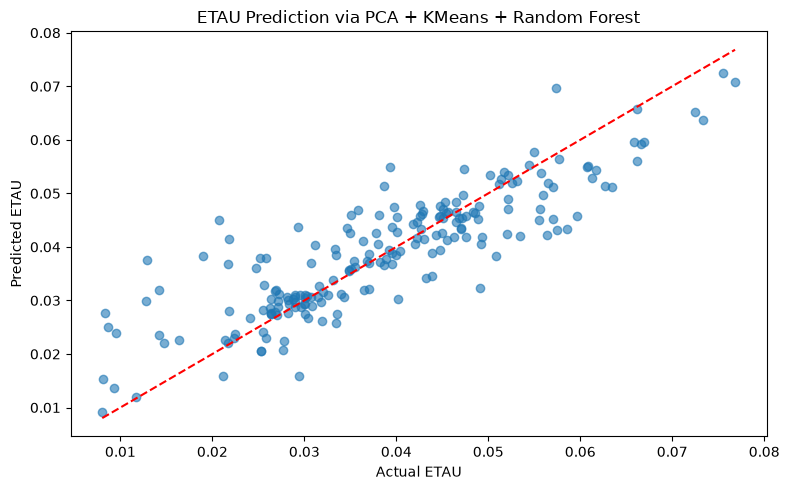

In [ ]:


def clean_idl_var(arr):
    arr = np.asanyarray(arr)
    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
    return arr.flatten().astype(np.float64)

local_path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'
data = readsav(local_path, python_dict=True)

mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

beam_features = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C']
core_features = ['TOTPWR', 'TE', 'NEUTT', 'AVGMODEN', 'NUMCHI']
target_name = 'ETAU'

data_dict = {}
for name in beam_features + core_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

df = pd.DataFrame(data_dict)

df_clean = df[df[target_name] > 0].copy()
lower_bound = df_clean[target_name].quantile(0.01)
upper_bound = df_clean[target_name].quantile(0.99)
df_clean = df_clean[(df_clean[target_name] >= lower_bound) & (df_clean[target_name] <= upper_bound)].reset_index(drop=True)

# Unsupervised feature learning
X_raw = df_clean[beam_features + core_features].astype(float)
X_scaled = StandardScaler().fit_transform(X_raw)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Build the model input from unsupervised components + cluster label
X_model = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
X_model['Beam_Regime'] = cluster_labels

df_clean['Beam_Regime'] = cluster_labels
y = df_clean[target_name].values

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

# Predict ETAU from unsupervised features
reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_train, np.log1p(y_train))
pred = np.expm1(reg.predict(X_test))

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"ETAU R^2: {r2:.3f}")
print(f"ETAU RMSE: {rmse:.3f}")

cluster_profiles = (
    df_clean.groupby('Beam_Regime')[beam_features + ['TOTPWR', target_name]]
    .mean()
)
print("\n--- Beam Regime Profiles ---")
display(cluster_profiles)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual ETAU")
plt.ylabel("Predicted ETAU")
plt.title("ETAU Prediction via PCA + KMeans + Random Forest")
plt.tight_layout()
plt.show()